# VHF Radio Agent — From Text to Agentic Training Data
## Auto Pilot Project · VHF Protocol Module

**Pipeline adapted from:**  
[IRTM Tutorial 13 — From Text to Agentic Training Data](https://github.com/TextMiningUM/IRTM-Student/tree/main/Assignments/13%20agentic_training_data) (Jan Scholtes, Maastricht University)

---

### Learning goals
By the end of this notebook you will be able to:

1. Convert raw text and PDF content into a **hierarchical JSON ontology** per document.
2. Extract six artifact families: RAG chunks, reranker triplets, concept graph, SFT trajectories, RLHF preference pairs, multi-hop chains.
3. Benchmark a **12-stage pipeline** (LLM → RAG → KG-RAG → SFT → RLHF → Agent) against the 540-question VHF evaluation set.
4. Fine-tune **Qwen2.5-7B-Instruct** with QLoRA (4-bit NF4) on the generated VHF training artifacts.
5. Compress the fine-tune with AWQ quantization + layer pruning + knowledge distillation.

---

## Repository layout — where VHF data & models live

The Auto Pilot project will host multiple maritime-domain agents (VHF, COLREG, Map reading, VHF exchanges, …). Each domain has **its own notebook** with **its own subfolders** under `Data/` and `_models/`. Anything shared across domains (Qwen base weights, `.env`, the Python scripts) stays at the workspace root.

```
Auto Pilot/
├── VHF_Agent_Training_Pipeline.ipynb   ← THIS notebook (VHF domain)
├── COLREG_Agent_Training_Pipeline.ipynb   (future — same shape, own Data/COLREG/ + _models/COLREG/)
├── ...
│
├── Data/
│   └── VHF/                           ← ALL VHF-domain data
│       ├── VHFProtocol/               ← training source documents (auto-discovered)
│       ├── VHF_Eval/                  ← held-out evaluation material — NEVER goes into training
│       │   ├── VHF Exam Questions.txt        (540 open questions, 27 SRC sections)
│       │   ├── vhf_gold_answers.json         (540 hand-authored gold Q&A + expected_points)
│       │   ├── examquestions2.pdf
│       │   ├── Seamanship-Centre-…pdf
│       │   ├── SRC-Exam-candidate-notes.pdf
│       │   └── VHF quiz ball.pdf
│       ├── VHF_JSON/                  ← one hierarchical JSON per source document (§ 8 output)
│       └── VHF_Agents_Training/       ← RAG chunks, embeddings, KG, reasoning traces,
│                                        SFT/DPO/reflection JSONL, ablation results, eval summaries
│
├── _models/
│   ├── hf_cache/                      ← Qwen base weights (~10 GB)  — SHARED across all domains
│   └── VHF/                           ← VHF-only fine-tuned artefacts
│       ├── vhf_qwen_sft_lora/         (§ 14 stage 1 output)
│       ├── vhf_qwen_dpo_lora/         (§ 14 stage 2 output)
│       ├── vhf_qwen_reflect_lora/     (§ 14 stage 3 output)
│       ├── VHF-QWEN/                  (§ 15 merged model — deployable)
│       ├── VHF-QWEN-awq-int4/         (§ 17 AWQ-quantised)
│       ├── VHF-QWEN-pruned/           (§ 18 layer-pruned)
│       └── DistillVHF-QWEN/           (§ 19 distilled student)
│
├── .env                               ← OPENAI_API_KEY (gitignored)
└── *.py                               ← shared training/eval scripts
```

### Why this split?
- **Training data (`Data/VHF/VHFProtocol/`) and eval data (`Data/VHF/VHF_Eval/`) live in different folders** so the eval set is impossible to accidentally leak into training. All build scripts (`build_sft.py`, `build_rlhf.py`, `build_multihop.py`, `build_reflection.py`) filter every generated question against `vhf_gold_answers.json` (cosine ≥ 0.85 → dropped) as a second line of defence.
- **New PDF/TXT/MD files dropped into `Data/VHF/VHFProtocol/` are auto-discovered** in § 8.1 and flow through the entire pipeline; every downstream stage is idempotent-with-staleness-detection and re-runs only when its inputs change.
- **`_models/hf_cache/` is shared** across all domain notebooks — Qwen2.5-7B in NF4 is ~5 GB and downloading it once for VHF, again for COLREG, etc. would be wasteful.
- **`_models/VHF/` is domain-scoped** so a future `_models/COLREG/` next to it won't clash.

### File classification for training sources

Official protocols and regulations in `Data/VHF/VHFProtocol/` get hand-curated `source_type`/`publisher` values in `SOURCE_CLASSIFICATION` (§ 8.1). Newly dropped-in files start as `("reference", "Auto", "en")`; override the entry to give them a better classification. Manually curated entries include: `VHF-procedures-Scheldt-area-EN.md`, `IMO standard marine comms phrases.pdf`, `CEPT Regulations.pdf`, `PHONETIC ALPHABET.pdf`, `Ship radio guidance for licencing.pdf`, `mgn375.pdf`, `mgn_324.pdf`, `VHF RADIO REGULATIONS.pdf`, `BoatUS.txt`, `CompleteGuideVHF.txt`, `VHFPro.txt`, `MarinePublicVHF.txt`, `NZC VHF.txt`.

Ignored:

| File | Reason |
|---|---|
| `NL-Marifoon-procedures-7.4.pdf` | Dutch language — set to `None` in `SOURCE_CLASSIFICATION` |

---

### Pipeline overview

```
Data/VHF/VHF_Eval/         Data/VHF/VHFProtocol/
      |                          |
      |     § 8  Parse to hierarchical JSON  → Data/VHF/VHF_JSON/
      |     § 9  Chunk + embed (RAG corpus)  → Data/VHF/VHF_Agents_Training/
      |     § 10 Knowledge Graph  (concept + adjacency edges)
      |     § 11 Reasoning traces (one gpt-4o-mini call per chunk)
      |     § 12 SFT direct + CoT + RAG + multi-hop + DPO + reflection
      |                          |
      ▼                          ▼
  540 gold Q&A  ◄──── § 13 Prompt ablation (V0..V3 on base Qwen)
                                 |
                                 ▼
                    § 14 QLoRA fine-tune (SFT → DPO → reflection)  → _models/VHF/*_lora/
                    § 15 Merge adapters  → _models/VHF/VHF-QWEN/
                    § 16 Evaluate on 540 Q  (no prompt tricks)
                    § 17 AWQ int4    → _models/VHF/VHF-QWEN-awq-int4/
                    § 18 Layer pruning → _models/VHF/VHF-QWEN-pruned/
                    § 19 Knowledge distillation → _models/VHF/DistillVHF-QWEN/
                    § 20 Final comparison
```

---
## § 0 — Environment Setup

Install all required packages. Run once; idempotent thereafter.  
Tier-2 packages (`torch`, `transformers`, `peft`, `trl`) are large — comment them out if you only want to run the Tier-1 prompt-only evaluation.

In [1]:
import subprocess, sys, time
from pathlib import Path

packages = [
    # Core inference (API clients)
    "openai>=1.40.0",
    "anthropic>=0.34.0",
    "tiktoken>=0.7.0",
    # Retrieval / embeddings
    "sentence-transformers>=2.7.0",
    "scikit-learn>=1.4.0",
    # Data
    "pandas>=2.2.0",
    "numpy>=1.26.0",
    "networkx>=3.2",
    # PDF extraction
    "pdfplumber>=0.11.0",
    # Progress + plotting
    "tqdm>=4.66.0",
    "matplotlib>=3.8.0",
    # HuggingFace stack (torch is installed separately in § 0.1 with CUDA support)
    "transformers>=4.40.0",
    "peft>=0.10.0",
    "trl>=0.8.0",
    "accelerate>=0.29.0",
]

t0 = time.time()
print("[setup] Installing / verifying dependencies (excluding torch)...", flush=True)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
print(f"[setup] Done in {time.time()-t0:.1f}s", flush=True)

# bitsandbytes: 4-bit NF4 quantisation for QLoRA. Native Windows support since 0.43+.
# Install separately because it can fail on some platforms and we want a clear error.
print("\n[setup] Installing bitsandbytes (for 4-bit Qwen quantisation)...", flush=True)
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bitsandbytes>=0.43.0"])
    print("[setup] bitsandbytes installed ✅")
except subprocess.CalledProcessError as e:
    print(f"[setup] ⚠️  bitsandbytes install failed ({e}). Qwen will load in bf16 instead of 4-bit.")


[setup] Installing / verifying dependencies (excluding torch)...
[setup] Done in 1.3s

[setup] Installing bitsandbytes (for 4-bit Qwen quantisation)...
[setup] bitsandbytes installed ✅


### § 0.1 — Install CUDA-aware PyTorch

Auto-detects NVIDIA GPU via `nvidia-smi` and installs the matching PyTorch wheel:
- **NVIDIA GPU present** → `torch+cu124` (CUDA 12.4 runtime, works with driver ≥ 550)
- **No NVIDIA GPU** → CPU-only build

This is separate from § 0 because `pip install torch>=2.2.0` without an index URL defaults to the CPU wheel — the most common cause of "why is my laptop GPU not being used?"

In [2]:
import subprocess, sys, shutil, re, time

def _detect_nvidia_gpu() -> tuple[bool, str]:
    """Return (has_gpu, info_string) by parsing nvidia-smi."""
    if shutil.which("nvidia-smi") is None:
        return False, "nvidia-smi not found on PATH"
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,driver_version,memory.total",
             "--format=csv,noheader"],
            text=True, timeout=10,
        ).strip()
        return True, out
    except Exception as e:
        return False, f"nvidia-smi failed: {e}"


def _current_torch_status() -> str:
    """Return a short description of currently installed torch, or 'not installed'."""
    try:
        import torch as _t
        return f"torch=={_t.__version__} (cuda_available={_t.cuda.is_available()})"
    except Exception:
        return "not installed"


has_gpu, gpu_info = _detect_nvidia_gpu()
print(f"[gpu-detect] {gpu_info}")
print(f"[torch-current] {_current_torch_status()}")

# Decide which index URL to use
if has_gpu:
    index_url = "https://download.pytorch.org/whl/cu124"
    print(f"[install] NVIDIA GPU detected — installing torch from {index_url}")
else:
    index_url = "https://download.pytorch.org/whl/cpu"
    print(f"[install] No NVIDIA GPU — installing CPU-only torch from {index_url}")

# Only (re)install if current torch does not match desired CUDA state
try:
    import torch
    need_reinstall = has_gpu != torch.cuda.is_available()
except ImportError:
    need_reinstall = True

if need_reinstall:
    t0 = time.time()
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--upgrade",
        "torch", "torchvision", "torchaudio",
        "--index-url", index_url,
    ])
    print(f"[install] Done in {time.time()-t0:.1f}s — RESTART THE KERNEL, then re-run.")
else:
    print("[install] Skipped: existing torch already matches the desired CUDA state.")


[gpu-detect] NVIDIA GeForce RTX 4070 Laptop GPU, 596.08, 8188 MiB
[torch-current] torch==2.6.0+cu124 (cuda_available=True)
[install] NVIDIA GPU detected — installing torch from https://download.pytorch.org/whl/cu124
[install] Skipped: existing torch already matches the desired CUDA state.


### § 0.2 — GPU sanity check

Verifies that PyTorch actually sees the GPU and can allocate on it.  
If this cell prints `❌ CUDA NOT AVAILABLE` you'll fall back to CPU inference for Qwen2.5-7B — technically works but takes 20+ hours for 540 questions.

Common fixes if CUDA is missing:
- **Re-run § 0.1 and restart the kernel** — pip may have installed the CPU wheel earlier
- **Update your NVIDIA driver** to ≥ 550 (CUDA 12.4 compatible)
- **Laptop with hybrid graphics** → open Windows Graphics Settings → set Python to *High performance* → restart

In [3]:
import platform, sys, time
import torch

print(f"Python              : {sys.version.split()[0]}")
print(f"Platform            : {platform.platform()}")
print(f"PyTorch             : {torch.__version__}")
print(f"CUDA build          : {torch.version.cuda}")
print(f"cuDNN               : {torch.backends.cudnn.version()}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    print("\n❌ CUDA NOT AVAILABLE — Qwen2.5-7B will fall back to CPU (very slow).")
    print("   Re-run § 0.1 and restart the kernel, or check NVIDIA driver ≥ 550.")
else:
    n = torch.cuda.device_count()
    print(f"GPU count           : {n}")
    for i in range(n):
        props = torch.cuda.get_device_properties(i)
        print(f"\nGPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Compute capability: {props.major}.{props.minor}")
        print(f"  Total VRAM        : {props.total_memory / 1024**3:.1f} GB")

    # Quick allocate + matmul benchmark
    print("\n[benchmark] fp16 matmul on GPU 0 (2048×2048)...")
    torch.cuda.synchronize()
    t0 = time.time()
    a = torch.randn(2048, 2048, device="cuda:0", dtype=torch.float16)
    b = torch.randn(2048, 2048, device="cuda:0", dtype=torch.float16)
    for _ in range(20):
        c = a @ b
    torch.cuda.synchronize()
    elapsed = time.time() - t0
    tflops = (20 * 2 * 2048**3) / elapsed / 1e12
    print(f"  20× matmul in {elapsed*1000:.1f} ms  →  ~{tflops:.1f} TFLOPS fp16")

    # bitsandbytes sanity check (needed for 4-bit NF4)
    print("\n[bitsandbytes] checking 4-bit quantisation support...")
    try:
        import bitsandbytes as bnb
        print(f"  bitsandbytes {bnb.__version__} ✅")
    except Exception as e:
        print(f"  ⚠️  bitsandbytes not available ({e.__class__.__name__}: {e})")
        print("     Qwen2.5-7B will load in bf16 (~14 GB VRAM) instead of 4-bit (~5 GB).")

    # Rough VRAM budget estimate for Qwen2.5-7B in 4-bit NF4
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"\n[budget] Qwen2.5-7B-Instruct memory footprint:")
    print(f"  4-bit NF4 (recommended) : ~5 GB VRAM  {'✅ fits' if total_gb >= 6 else '❌ tight'}")
    print(f"  bf16                    : ~14 GB VRAM {'✅ fits' if total_gb >= 15 else '❌ too small'}")
    print(f"  fp32                    : ~28 GB VRAM {'✅ fits' if total_gb >= 30 else '❌ too small'}")


Python              : 3.13.14
Platform            : Windows-11-10.0.26200-SP0
PyTorch             : 2.6.0+cu124
CUDA build          : 12.4
cuDNN               : 90100
CUDA available      : True
GPU count           : 1

GPU 0: NVIDIA GeForce RTX 4070 Laptop GPU
  Compute capability: 8.9
  Total VRAM        : 8.0 GB

[benchmark] fp16 matmul on GPU 0 (2048×2048)...
  20× matmul in 147.3 ms  →  ~2.3 TFLOPS fp16

[bitsandbytes] checking 4-bit quantisation support...
  bitsandbytes 0.50.2 ✅

[budget] Qwen2.5-7B-Instruct memory footprint:
  4-bit NF4 (recommended) : ~5 GB VRAM  ✅ fits
  bf16                    : ~14 GB VRAM ❌ too small
  fp32                    : ~28 GB VRAM ❌ too small


---
## § 1 — Parse VHF Exam Questions

The file contains 540 open-ended questions across 27 SRC sections.  
We parse it into a list of dicts: `{id, section_id, section_title, type, question}`.  
Gold reference answers are **not** in the source file — we generate them in § 2.

In [17]:
import re, json
from pathlib import Path

# ── Data locations ────────────────────────────────────────────────────────
# WORKSPACE     : project root (contains scripts, .venv, _models, .env)
# VHF_ROOT      : Data/VHF — all VHF-domain data lives here
# DATA_DIR      : training documents (RAG / SFT / KG / DPO / reflection)
# EVAL_DIR      : held-out evaluation material — NEVER goes into training
# EVAL_FILE     : the 540-question exam text
WORKSPACE = Path(r"C:\Users\jcsch\Documents\Python\Auto Pilot")
VHF_ROOT  = WORKSPACE / "Data" / "VHF"
DATA_DIR  = VHF_ROOT / "VHFProtocol"
EVAL_DIR  = VHF_ROOT / "VHF_Eval"
EVAL_FILE = EVAL_DIR / "VHF Exam Questions.txt"


def parse_exam_questions(path: Path) -> list[dict]:
    """Parse the SRC exam questions file into structured records."""
    lines = path.read_text(encoding="utf-8").splitlines()

    section_re = re.compile(r"^(\d+\.\d+)\s+(.*?)\s+\((Theory|Practical)\s*-\s*(\d+)\)")
    questions   = []
    current     = {}
    q_counter   = 0

    for line in lines:
        line = line.strip()
        if not line:
            continue

        m = section_re.match(line)
        if m:
            current = {
                "section_id":    m.group(1),
                "section_title": m.group(2).strip(),
                "type":          m.group(3),
                "expected_n":    int(m.group(4)),
            }
            q_counter = 0
            continue

        if line.lower() in {"theoretical part", "practical part", "permanent link"}:
            continue

        if current and line:
            q_counter += 1
            sec = current["section_id"]
            questions.append({
                "id":            f"vhf_{sec}_{q_counter:02d}",
                "section_id":    sec,
                "section_title": current["section_title"],
                "type":          current["type"],
                "question":      line,
                "expected_points": [],
                "gold_answer":   "",
            })

    return questions

eval_questions = parse_exam_questions(EVAL_FILE)

# Summary
import pandas as pd
df = pd.DataFrame(eval_questions)
print(f"Eval file              : {EVAL_FILE}")
print(f"Total questions parsed : {len(eval_questions)}")
print(f"Sections               : {df['section_id'].nunique()}")
print(f"Theory / Practical     : {df['type'].value_counts().to_dict()}")
print()
print(df.groupby(["section_id", "section_title", "type"])
         .size()
         .reset_index(name="n_questions")
         .to_string(index=False))

Eval file              : C:\Users\jcsch\Documents\Python\Auto Pilot\Data\VHF\VHF_Eval\VHF Exam Questions.txt
Total questions parsed : 540
Sections               : 27
Theory / Practical     : {'Theory': 300, 'Practical': 240}

section_id                                                            section_title      type  n_questions
       1.1                                               Marine VHF Legal Framework    Theory           20
      1.10                                            Urgency Voice Calls (PAN PAN)    Theory           20
      1.11                                            Safety Voice Calls (SECURITÉ)    Theory           20
      1.12                                                      Routine Voice Calls    Theory           20
      1.13                                          Digital Selective Calling (DSC)    Theory           20
      1.14                                                 GMDSS and Its Components    Theory           20
      1.15               

---
## § 2 — Generate Gold Reference Answers

The exam questions have no model answers in the source file.  
We generate a reference answer + `expected_points` for every question using a strong LLM (GPT-4o-mini).  
Results are **cached to disk** — re-runs skip API calls.

> If no API key is available, the gold answers are left empty and only  
> `AnsRel` and `Safe` (the two free metrics) will be meaningful in § 4.

In [18]:
import os, getpass, json
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
# WORKSPACE / VHF_ROOT / EVAL_DIR already defined in § 1; re-bound here so
# § 2 runs stand-alone as well.
WORKSPACE       = Path(r"C:\Users\jcsch\Documents\Python\Auto Pilot")
VHF_ROOT        = WORKSPACE / "Data" / "VHF"
EVAL_DIR        = VHF_ROOT / "VHF_Eval"
CACHE_DIR       = VHF_ROOT / "VHF_Agents_Training"     # RAG / KG / traces / SFT / DPO / reflection
GOLD_CACHE_FILE = EVAL_DIR / "vhf_gold_answers.json"   # held-out eval asset
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Gold-answer source ────────────────────────────────────────────────────
# vhf_gold_answers.json is the committed, hand-authored evaluation set
# (540 records). If it exists, we do NOT prompt for any API key.
#
# The API scaffolding below is only triggered when the file is MISSING —
# in that case we offer to (re)generate the gold set with a frontier LLM.
# See § 3 markdown for the human-review workflow this expects.

GOLD_MODEL = "claude-opus-4-5"        # only used when regenerating from scratch

gold_client  = None
gold_backend = "none"

if GOLD_CACHE_FILE.exists():
    print(f"Gold file      : {GOLD_CACHE_FILE}")
    print(f"Cache exists   : True ({GOLD_CACHE_FILE.stat().st_size/1024:.1f} KB)")
    print(f"Gold source    : human-authored — no API call, no key prompt")
    GOLD_MODEL = "human-authored"
else:
    print(f"Gold file      : {GOLD_CACHE_FILE}  ⚠️  NOT FOUND")
    print(f"Requesting {GOLD_MODEL} client so § 3 can regenerate the gold set.")
    gold_backend = "anthropic" if "claude" in GOLD_MODEL else "openai"

    if gold_backend == "anthropic":
        _key = os.environ.get("ANTHROPIC_API_KEY", "").strip()
        if not _key:
            _key = getpass.getpass(
                f"Anthropic API key for {GOLD_MODEL} (Enter to skip): "
            ).strip()
        if _key:
            import anthropic
            gold_client = anthropic.Anthropic(api_key=_key)
            print(f"Anthropic client ready  ({GOLD_MODEL})")
        else:
            print("No Anthropic key — § 3 will not be able to build gold; "
                  "obtain vhf_gold_answers.json from the repo instead.")
    else:
        _key = os.environ.get("OPENAI_API_KEY", "").strip()
        if not _key:
            _key = getpass.getpass(
                f"OpenAI API key for {GOLD_MODEL} (Enter to skip): "
            ).strip()
        if _key:
            from openai import OpenAI
            gold_client = OpenAI(api_key=_key)
            print(f"OpenAI client ready  ({GOLD_MODEL})")
        else:
            print("No OpenAI key — § 3 will not be able to build gold; "
                  "obtain vhf_gold_answers.json from the repo instead.")

Gold file      : C:\Users\jcsch\Documents\Python\Auto Pilot\Data\VHF\VHF_Eval\vhf_gold_answers.json
Cache exists   : True (436.7 KB)
Gold source    : human-authored — no API call, no key prompt


---
## § 3 — Gold Reference Answers

For every question we need:
- `gold_answer` — a complete, authoritative answer (3–6 sentences)
- `expected_points` — 2–5 atomic facts the answer must contain (used by Cover / NumHit / LitHit)

### Approach used in this project

**We have authored the gold standard ourselves** (with domain expertise), and stored it at:

📄 [`vhf_gold_answers.json`](vhf_gold_answers.json)

This is the ground-truth file the rest of the notebook loads. No API call is made in § 3 during a normal run — the cell below simply reads this file.

### Alternative (kept for reference below)

If you were building a gold standard for a **new domain from scratch**, you would typically:

1. **Generate a first draft with a strong LLM** — Claude Opus 4.5 or GPT-4o, one call per question, cached to disk. This is what the `generate_gold_answers()` function shown below does. Cost estimate for 540 questions:

    | Model | ~Input tok | ~Output tok | Approx. cost |
    |---|---|---|---|
    | claude-opus-4-5 | 135 K | 200 K | ~$18 |
    | claude-sonnet-4-5 | 135 K | 200 K | ~$3 |
    | gpt-4o | 135 K | 200 K | ~$3 |

2. **Human review pass** — a domain expert (here: an SRC-certified radio operator or examiner) must read every generated answer, correct factual errors, verify that `expected_points` are truly the discriminating facts, and remove hedging or hallucinated details. LLM-generated gold without human validation is **not** gold — it is a plausible-sounding baseline that will systematically bias every downstream metric.

3. **Freeze the reviewed file** — commit it once, treat it as an immutable evaluation asset. Any change invalidates all previous benchmark numbers.

The two cells below implement step 1 (LLM draft generation). They will simply reuse the cache in `vhf_gold_answers.json` if it already exists — which is our case.

In [19]:
import time
from tqdm.auto import tqdm

# ── Fast path: gold already on disk ───────────────────────────────────────
if GOLD_CACHE_FILE.exists():
    records = json.loads(GOLD_CACHE_FILE.read_text(encoding="utf-8"))
    by_id   = {r["id"]: r for r in records}
    eval_questions_with_gold = [by_id.get(q["id"], q) for q in eval_questions]

    n_with_gold = sum(1 for q in eval_questions_with_gold if q.get("gold_answer"))
    n_with_pts  = sum(1 for q in eval_questions_with_gold if q.get("expected_points"))
    print(f"Loaded gold      : {len(records)} records from {GOLD_CACHE_FILE.name}")
    print(f"With gold_answer : {n_with_gold} / {len(eval_questions_with_gold)}")
    print(f"With expected_pts: {n_with_pts}  / {len(eval_questions_with_gold)}")

    ex = next((q for q in eval_questions_with_gold if q.get("gold_answer")), None)
    if ex:
        print(f"\nExample [{ex['id']}]  section {ex['section_id']} — {ex['section_title']}")
        print(f"  Q : {ex['question']}")
        print(f"  A : {ex['gold_answer'][:200]}...")
        print(f"  EP: {ex['expected_points']}")

else:
    # ── Fallback: regenerate from scratch with the LLM configured in § 2 ──
    # Only reachable when vhf_gold_answers.json is missing. Requires a client
    # (gold_client) and produces LLM-drafted answers that MUST be human-reviewed
    # before being used as an evaluation asset — see § 3 markdown.

    GOLD_SYSTEM = (
        "You are an expert maritime VHF radio examiner with deep knowledge of GMDSS, "
        "SRC (Short Range Certificate) regulations, IMO SMCP, ITU Radio Regulations, "
        "and UK/EU/international maritime communication procedures. "
        "Answer exam questions accurately, concisely, and in examiner-approved language."
    )

    GOLD_PROMPT_TEMPLATE = """\
SRC exam question (section {section_id} — {section_title}, {type}):

{question}

Provide:
1. A complete, authoritative answer in 3–6 sentences.
2. A JSON list called "expected_points" containing 2–5 atomic, verifiable facts \
that a correct answer MUST include (exact terms, channel numbers, pro-words, \
regulation names, or procedural steps as appropriate).

Respond in this exact JSON format:
{{
  "gold_answer": "...",
  "expected_points": ["fact 1", "fact 2", ...]
}}"""

    def _call_gold(question_record: dict) -> dict:
        prompt = GOLD_PROMPT_TEMPLATE.format(**question_record)
        if gold_backend == "anthropic" and gold_client:
            msg = gold_client.messages.create(
                model=GOLD_MODEL, max_tokens=600, temperature=0.1,
                system=GOLD_SYSTEM,
                messages=[{"role": "user", "content": prompt}],
            )
            raw = msg.content[0].text.strip()
        elif gold_backend == "openai" and gold_client:
            resp = gold_client.chat.completions.create(
                model=GOLD_MODEL,
                messages=[
                    {"role": "system", "content": GOLD_SYSTEM},
                    {"role": "user",   "content": prompt},
                ],
                max_tokens=600, temperature=0.1,
                response_format={"type": "json_object"},
            )
            raw = resp.choices[0].message.content.strip()
        else:
            return {}
        if raw.startswith("```"):
            raw = "\n".join(raw.splitlines()[1:]).rstrip("`").strip()
        try:
            return json.loads(raw)
        except json.JSONDecodeError:
            return {}

    if gold_client is None:
        raise RuntimeError(
            "vhf_gold_answers.json is missing AND no API client was created in § 2. "
            "Pull the file from the repo, or re-run § 2 with a key."
        )

    print(f"Calling {GOLD_MODEL} for {len(eval_questions)} questions "
          "(cost ~$3–$18 depending on model)...")
    cache: dict[str, dict] = {}
    for q in tqdm(eval_questions, desc="Generating gold answers"):
        result = _call_gold(q)
        if result:
            cache[q["id"]] = {**q,
                              "gold_answer":     result.get("gold_answer", ""),
                              "expected_points": result.get("expected_points", [])}
        else:
            cache[q["id"]] = q
        time.sleep(0.3)

    GOLD_CACHE_FILE.write_text(
        json.dumps(list(cache.values()), indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    eval_questions_with_gold = [cache[q["id"]] for q in eval_questions]
    print(f"\nSaved {len(cache)} records to {GOLD_CACHE_FILE}")
    print("⚠️  This is an LLM DRAFT — have a domain expert review before benchmarking.")

Loaded gold      : 540 records from vhf_gold_answers.json
With gold_answer : 540 / 540
With expected_pts: 540  / 540

Example [vhf_1.1_01]  section 1.1 — Marine VHF Legal Framework
  Q : Explain why many administrations legally require a dedicated operator certificate to use a marine VHF radio on a leisure vessel.
  A : Marine VHF equipment is powerful enough to interfere with distress and safety traffic across international waters, so the ITU Radio Regulations require that operators demonstrate minimum competence. N...
  EP: ['ITU Radio Regulations require operator competence', 'SRC / Short Range Certificate is the standard leisure qualification', 'protects distress and safety traffic on Channel 16 and DSC', 'minimum competence in procedures, phraseology and DSC operation']


---
## § 4 — Tutorial 13 Metrics Engine

Verbatim implementation of all metrics from Tutorial 13 § 7.6–7.8:

| Metric | Acronym | Cost | What it measures |
|---|---|---|---|
| RAGAS Semantic Similarity | SemSim | free (embedding) | Cosine similarity answer ↔ gold reference |
| RAGAS Answer Relevancy | AnsRel | free (embedding) | Cosine similarity answer ↔ question |
| RAGAS Faithfulness | Faith | API call | Fraction of answer claims supported by context |
| RAGAS Answer Correctness | Correct | API call | LLM judge 1–5 score vs reference |
| Safety Score | Safe | free (heuristic) | Absence of harmful content |
| Expected-Point Coverage | Cover | free (substring) | Fraction of gold `expected_points` present |
| Numeric-Token Recall | NumHit | free (regex) | Exact numbers / channel codes recalled |
| Literal-Phrase Recall | LitHit | free (substring) | Verbatim key phrases recalled |
| **Composite** | **Comp** | — | Unweighted mean of applicable metrics |

`Faith` is skipped for the bare-LLM stage (no retrieved context).

In [20]:
import re, json, numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Loading sentence-transformer model...", flush=True)
_sem_model = SentenceTransformer("all-MiniLM-L6-v2")
print("all-MiniLM-L6-v2 ready.")

# ── § 7.7  Embedding-based metrics (free) ────────────────────────────────
def ragas_semantic_similarity(answer: str, reference: str) -> float | None:
    if not answer or not reference:
        return None
    embs = _sem_model.encode([answer, reference], normalize_embeddings=True)
    return round(float(np.dot(embs[0], embs[1])), 3)

def ragas_answer_relevancy(question: str, answer: str) -> float | None:
    if not question or not answer:
        return None
    embs = _sem_model.encode([question, answer], normalize_embeddings=True)
    return round(float(np.dot(embs[0], embs[1])), 3)

# ── § 7.7  LLM-based metrics (one API call each) ─────────────────────────
def ragas_faithfulness(answer: str, context: str, max_ctx: int = 800) -> float | None:
    """Fraction of answer claims supported by retrieved context."""
    if not gold_client or not answer or not context:
        return None
    prompt = (
        f"Context:\n{context[:max_ctx]}\n\nAnswer:\n{answer[:600]}\n\n"
        "List the key factual claims in the answer (max 5). "
        "For each claim state whether it can be inferred from the context. "
        'Return ONLY valid JSON: {"claims": [{"claim": "...", "supported": true}]}'
    )
    raw = _llm_judge_call(prompt, max_tokens=300)
    try:
        raw = re.sub(r"^```[a-z]*\s*", "", raw, flags=re.MULTILINE)
        raw = re.sub(r"```\s*$", "", raw, flags=re.MULTILINE).strip()
        claims = json.loads(raw).get("claims", [])
        if not claims:
            return None
        return round(sum(1 for c in claims if c.get("supported")) / len(claims), 3)
    except Exception:
        return None

def ragas_answer_correctness(question: str, answer: str, reference: str) -> float | None:
    """LLM judge 1–5 score normalised to [0, 1]."""
    if not gold_client or not answer:
        return None
    ref_text = reference[:400] if reference else "(no reference)"
    prompt = (
        f"Question: {question}\nReference: {ref_text}\nAnswer: {answer[:600]}\n\n"
        "Score the answer from 1 to 5 where:\n"
        "1 = incorrect or irrelevant\n3 = partially correct\n5 = fully correct\n"
        'Return ONLY valid JSON: {"score": N}'
    )
    raw = _llm_judge_call(prompt, max_tokens=20)
    try:
        raw = re.sub(r"^```[a-z]*\s*", "", raw, flags=re.MULTILINE)
        raw = re.sub(r"```\s*$", "", raw, flags=re.MULTILINE).strip()
        return round(int(json.loads(raw).get("score", 3)) / 5.0, 3)
    except Exception:
        return None

def _llm_judge_call(prompt: str, max_tokens: int = 300) -> str:
    """Route to the oracle model for LLM-judge calls."""
    try:
        if gold_backend == "anthropic" and gold_client:
            msg = gold_client.messages.create(
                model=GOLD_MODEL, max_tokens=max_tokens, temperature=0,
                system="You are an impartial evaluator. Return only valid JSON.",
                messages=[{"role": "user", "content": prompt}],
            )
            return msg.content[0].text.strip()
        elif gold_backend == "openai" and gold_client:
            resp = gold_client.chat.completions.create(
                model=GOLD_MODEL, max_tokens=max_tokens, temperature=0,
                messages=[
                    {"role": "system", "content": "You are an impartial evaluator. Return only valid JSON."},
                    {"role": "user",   "content": prompt},
                ],
            )
            return resp.choices[0].message.content.strip()
    except Exception as e:
        print(f"  [judge error] {e}")
    return ""

# ── § 7.6  Deterministic metrics (free) ──────────────────────────────────
_VHF_DEFENSIVE = [
    "authorised", "authorized", "safety", "distress", "emergency",
    "procedures", "regulations", "protocol", "monitoring",
]
_VHF_RISKY = ["illegal", "prohibited", "forbidden", "violation"]

def safety_check(answer: str) -> float:
    """1.0 = safe; lower if answer promotes unlawful radio use."""
    if not answer:
        return 1.0
    al = answer.lower()
    if any(p in al for p in ["transmit false distress", "jam the channel", "interfere deliberately"]):
        return 0.0
    risk_hits = sum(al.count(t) for t in _VHF_RISKY)
    return round(max(0.0, 1.0 - 0.25 * risk_hits), 2)

def expected_point_coverage(answer: str, expected_points: list[str]) -> float:
    if not expected_points:
        return 1.0
    if not answer:
        return 0.0
    al = answer.lower()
    covered = sum(1 for p in expected_points if p.lower() in al)
    return round(covered / len(expected_points), 2)

def benchmark_critic(answer: str, expected_points: list[str]) -> dict:
    """Returns {coverage, missing}. Coverage uses 60% keyword match."""
    if not expected_points:
        return {"coverage": 1.0, "missing": []}
    if not answer:
        return {"coverage": 0.0, "missing": list(expected_points)}
    al = answer.lower()
    missing = []
    for pt in expected_points:
        ptl = pt.lower()
        if ptl in al:
            continue
        kws = re.findall(r"\b[a-z]{4,}\b", ptl)
        if kws and sum(1 for w in kws if w in al) / len(kws) >= 0.6:
            continue
        missing.append(pt)
    coverage = 1.0 - len(missing) / len(expected_points)
    return {"coverage": round(coverage, 2), "missing": missing}

# ── § 7.9  Strict recall metrics ─────────────────────────────────────────
_NUM_UNIT_RE = re.compile(
    r"(\d+(?:[.,]\d+)?(?:/\d+)?)\s*"
    r"(channel|ch\.?|MHz|kHz|watts?|W|nm|knots?|metres?|meters?|feet|"
    r"seconds?|minutes?|hours?|miles?|km|dB|Hz)?\b",
    re.IGNORECASE,
)
_NUM_RAW_RE = re.compile(r"(?<![\w.])(\d+(?:[.,]\d+)?(?:/\d+)?)(?![\w.])")

def numeric_recall(answer: str, expected_points: list[str]) -> float | None:
    if not expected_points:
        return None
    a = (answer or "").lower()
    targets: set[str] = set()
    for ep in expected_points:
        for num, unit in _NUM_UNIT_RE.findall(ep):
            n = num.replace(",", ".").lower()
            targets.add(n)
            if unit:
                targets.add(f"{n} {unit.lower()}")
        for n in _NUM_RAW_RE.findall(ep):
            if len(n) >= 2 or "/" in n or "." in n:
                targets.add(n.replace(",", ".").lower())
    if not targets:
        return None
    hits = sum(1 for t in targets if t and t in a)
    return round(hits / len(targets), 3)

def literal_phrase_recall(answer: str, expected_points: list[str]) -> float | None:
    if not expected_points:
        return None
    a = (answer or "").lower()
    hits = 0
    for ep in expected_points:
        text = (ep or "").lower().strip()
        if not text:
            continue
        runs = [r.strip() for r in re.split(r"[^a-z0-9 \-/.]+", text)]
        runs = [r for r in runs if len(r.split()) >= 3]
        candidates = sorted(runs, key=len, reverse=True) if runs else [text]
        if any(c and c in a for c in candidates[:3]):
            hits += 1
    return round(hits / len(expected_points), 3)

# ── Composite score ───────────────────────────────────────────────────────
def compute_composite(ans_rel, correct, safe, cover, num_hit, lit_hit,
                      faith=None) -> float | None:
    components = [v for v in [ans_rel, correct, safe, cover, num_hit, lit_hit]
                  if v is not None]
    if faith is not None:
        components.append(faith)
    return round(sum(components) / len(components), 3) if components else None

METRIC_KEYS = ["SemSim", "AnsRel", "Faith", "Correct", "Safe",
               "Cover", "NumHit", "LitHit", "Composite"]

def score_record(q: dict, answer: str, context: str = "") -> dict:
    ref    = q.get("gold_answer", "")
    pts    = q.get("expected_points", [])
    sem    = ragas_semantic_similarity(answer, ref)
    ans    = ragas_answer_relevancy(q["question"], answer)
    fai    = ragas_faithfulness(answer, context) if context else None
    cor    = ragas_answer_correctness(q["question"], answer, ref)
    saf    = safety_check(answer)
    cov    = expected_point_coverage(answer, pts)
    num    = numeric_recall(answer, pts)
    lit    = literal_phrase_recall(answer, pts)
    comp   = compute_composite(ans, cor, saf, cov, num, lit, fai)
    return dict(SemSim=sem, AnsRel=ans, Faith=fai, Correct=cor,
                Safe=saf, Cover=cov, NumHit=num, LitHit=lit, Composite=comp)

print("Metrics engine loaded (Tutorial 13 § 7.6–7.9).")

Loading sentence-transformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7125.17it/s]


all-MiniLM-L6-v2 ready.
Metrics engine loaded (Tutorial 13 § 7.6–7.9).


---
## § 5 — Load Qwen2.5-7B-Instruct (base, no fine-tuning)

4-bit NF4 quantisation via bitsandbytes when CUDA is available; fp32 CPU fallback otherwise.  
This is the model being evaluated — no adapters, no RAG, pure parametric knowledge.

In [38]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

QWEN_MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

# Cache model files inside the project working directory (~5 GB for 4-bit Qwen2.5-7B)
QWEN_CACHE_DIR = WORKSPACE / "_models" / "hf_cache"
QWEN_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(QWEN_CACHE_DIR))
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

QWEN_SYSTEM = (
    "You are a maritime VHF radio operator. "
    "Answer the question accurately and concisely in 3–5 sentences."
)

def _load_qwen():
    global _qwen_tok, _qwen_model
    if globals().get("_qwen_model") is not None:
        return

    print(f"Loading {QWEN_MODEL_ID} (cache: {QWEN_CACHE_DIR})...", flush=True)
    _qwen_tok = AutoTokenizer.from_pretrained(
        QWEN_MODEL_ID, trust_remote_code=True, cache_dir=str(QWEN_CACHE_DIR),
    )
    if _qwen_tok.pad_token is None:
        _qwen_tok.pad_token = _qwen_tok.eos_token

    if torch.cuda.is_available():
        try:
            from transformers import BitsAndBytesConfig
            bnb = BitsAndBytesConfig(
                load_in_4bit=True, bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.bfloat16,
                bnb_4bit_use_double_quant=True,
            )
            _qwen_model = AutoModelForCausalLM.from_pretrained(
                QWEN_MODEL_ID, quantization_config=bnb,
                device_map={"": 0}, trust_remote_code=True,
                cache_dir=str(QWEN_CACHE_DIR),
            )
            print("  Loaded in 4-bit NF4 on GPU.")
        except Exception as e:
            print(f"  bitsandbytes unavailable ({e}) — loading in bfloat16.")
            _qwen_model = AutoModelForCausalLM.from_pretrained(
                QWEN_MODEL_ID, torch_dtype=torch.bfloat16,
                device_map={"": 0}, trust_remote_code=True,
                cache_dir=str(QWEN_CACHE_DIR),
            )
    else:
        print("  No CUDA — loading in float32 on CPU (slow).")
        _qwen_model = AutoModelForCausalLM.from_pretrained(
            QWEN_MODEL_ID, torch_dtype=torch.float32, trust_remote_code=True,
            cache_dir=str(QWEN_CACHE_DIR),
        )
    _qwen_model.eval()
    print(f"  Model ready.  Device: {next(_qwen_model.parameters()).device}")

_qwen_tok   = globals().get("_qwen_tok")
_qwen_model = globals().get("_qwen_model")
_load_qwen()

def call_qwen(question: str, max_new_tokens: int = 384) -> str:
    """Generate an answer from Qwen2.5-7B for a single question."""
    chat = [
        {"role": "system", "content": QWEN_SYSTEM},
        {"role": "user",   "content": question},
    ]
    prompt = _qwen_tok.apply_chat_template(
        chat, tokenize=False, add_generation_prompt=True
    )
    enc = _qwen_tok(prompt, return_tensors="pt",
                    truncation=True, max_length=1024).to(_qwen_model.device)
    with torch.no_grad():
        out = _qwen_model.generate(
            **enc, max_new_tokens=max_new_tokens,
            do_sample=False, temperature=1.0,
            pad_token_id=_qwen_tok.pad_token_id,
            eos_token_id=_qwen_tok.eos_token_id,
        )
    decoded = _qwen_tok.decode(
        out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True
    )
    return decoded.strip()

# Smoke test
print("\nSmoke test:", call_qwen("What is VHF Channel 16 used for?"))


Loading Qwen/Qwen2.5-7B-Instruct (cache: C:\Users\jcsch\Documents\Python\Auto Pilot\_models\hf_cache)...


Loading weights: 100%|██████████| 339/339 [00:17<00:00, 19.91it/s]


  Loaded in 4-bit NF4 on GPU.
  Model ready.  Device: cuda:0

Smoke test: VHF Channel 16 (156.800 MHz) is the international distress and safety communication channel. It is monitored continuously by coast stations and is used for calling for assistance or relaying information during emergencies.


---
## § 5.5 — LLM Judge Setup (OpenAI + persistent `.env`)

The metrics `Correct` (RAGAS Answer Correctness) and `Faith` (Faithfulness) need an LLM judge — a strong model that grades each Qwen answer against the gold reference.

We use **`gpt-4o-mini`** as judge:
- Cheap (~$0.15 per million input tokens, $0.60 per million output)
- Strong enough for pass/fail grading
- Fast (~0.7 s per call → ~6 min for 540 questions)

### Credentials

The key is stored in `.env` in the workspace root, then loaded on subsequent runs:
- First run: prompts for the key, writes it to `.env`
- Later runs: loads it automatically, no prompt

`.env` is already in `.gitignore` — the key stays on your laptop.

In [37]:
import os, getpass
from pathlib import Path
from openai import OpenAI

ENV_FILE    = WORKSPACE / ".env"
JUDGE_MODEL = "gpt-4o-mini"

def load_env(path: Path) -> dict[str, str]:
    """Tiny KEY=\"value\" .env loader (no dependency on python-dotenv)."""
    out = {}
    if not path.exists():
        return out
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        k, v = line.split("=", 1)
        out[k.strip()] = v.strip().strip('"').strip("'")
    return out

def save_env(path: Path, key: str, value: str) -> None:
    """Add/update KEY=value in .env, keeping other entries."""
    current = load_env(path)
    current[key] = value
    lines = [f'{k}="{v}"' for k, v in sorted(current.items())]
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

# Load any previously-saved env vars into the process
for k, v in load_env(ENV_FILE).items():
    os.environ.setdefault(k, v)

# Get / prompt for the OpenAI key
_openai_key = os.environ.get("OPENAI_API_KEY", "").strip()
if _openai_key:
    print(f"OPENAI_API_KEY loaded from {ENV_FILE.name} ({_openai_key[:8]}…)")
else:
    _openai_key = getpass.getpass("Enter your OpenAI API key (starts with sk-…): ").strip()
    if _openai_key:
        save_env(ENV_FILE, "OPENAI_API_KEY", _openai_key)
        os.environ["OPENAI_API_KEY"] = _openai_key
        print(f"Key saved to {ENV_FILE} (in .gitignore).")

# Build the judge client and rebind the module-level vars used by § 4 metrics
if _openai_key:
    judge_client = OpenAI(api_key=_openai_key)
    gold_client  = judge_client              # § 4 looks these up at call time
    gold_backend = "openai"
    GOLD_MODEL   = JUDGE_MODEL

    # Smoke test — one cheap call to confirm the key works
    try:
        resp = judge_client.chat.completions.create(
            model=JUDGE_MODEL, max_tokens=5, temperature=0,
            messages=[{"role": "user", "content": "Reply with the single word OK."}],
        )
        reply = resp.choices[0].message.content.strip()
        print(f"Judge ready — {JUDGE_MODEL}  ·  smoke test: {reply!r}")
    except Exception as e:
        print(f"⚠️  Judge smoke test failed: {e}")
else:
    print("No key entered — Faith and Correct will remain n/a.")


OPENAI_API_KEY loaded from .env (sk-proj-…)
Judge ready — gpt-4o-mini  ·  smoke test: 'OK'


### § 5.6 — Re-score cached answers with judge metrics

The Qwen answers from the smoke-test run are already in `_cache/vhf_qwen_base_results.json`. This cell re-runs *only* the metrics (Faith, Correct) on those cached answers — no new Qwen inference is needed.

Cost estimate for the 50-question smoke test: ~0.5¢ (fifty `gpt-4o-mini` calls).

In [39]:
from tqdm.auto import tqdm

RESULTS_CACHE = CACHE_DIR / "vhf_qwen_base_results.json"

def rescore_cached(cache_file: Path, force: bool = False) -> None:
    """Recompute metrics for every cached answer without re-running Qwen.

    force=False → skip records that already have a non-None Correct score.
    """
    if not cache_file.exists():
        print("No cached results found.")
        return

    records = json.loads(cache_file.read_text(encoding="utf-8"))
    todo = records if force else [
        r for r in records if r.get("metrics", {}).get("Correct") is None
    ]
    if not todo:
        print(f"All {len(records)} records already have judge metrics.")
        return

    print(f"Rescoring {len(todo)} / {len(records)} records with judge {GOLD_MODEL}...")
    for r in tqdm(todo, desc="rescoring"):
        r["metrics"] = score_record(r, r.get("qwen_answer", ""))

    cache_file.write_text(
        json.dumps(records, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    print(f"Done. Wrote {cache_file}")


rescore_cached(RESULTS_CACHE)


All 50 records already have judge metrics.


---
## § 6 — Evaluation: Qwen2.5-7B Base

Runs all Tutorial 13 metrics on the evaluation subset.  
Results are cached to `_cache/vhf_qwen_base_results.json` — re-running is free (any already-scored questions are skipped).  
LLM-judge metrics (`Correct`, `Faith`) require the oracle API; they are skipped if no key is set.

### Smoke test first (recommended)

Set `N_EVAL` below to a small number (e.g. 50) to verify the pipeline works end-to-end before committing to the full 540-question run.  
Later, set `N_EVAL = None` to evaluate all questions — the cache means the first 50 are not re-run.

In [40]:
from tqdm.auto import tqdm
import pandas as pd
import math

# ── Evaluation subset ─────────────────────────────────────────────────────
#  Set N_EVAL to a small number (50) for a smoke test; set to None for all 540.
#  Cached results are preserved between runs, so you never redo work.
N_EVAL = 50

RESULTS_CACHE = CACHE_DIR / "vhf_qwen_base_results.json"

def run_evaluation(questions: list[dict], cache_file: Path) -> list[dict]:
    """Answer all questions with Qwen and score with every Tutorial 13 metric."""
    cache: dict[str, dict] = {}
    if cache_file.exists():
        cache = {r["id"]: r for r in json.loads(cache_file.read_text(encoding="utf-8"))}
        print(f"Results cache: {len(cache)} entries loaded from disk.")

    needs = [q for q in questions if q["id"] not in cache]
    if needs:
        print(f"Running Qwen2.5-7B on {len(needs)} questions...", flush=True)
    else:
        print("All questions already in cache — nothing to run.")

    for q in tqdm(needs, desc="Qwen2.5-7B eval"):
        answer  = call_qwen(q["question"])
        metrics = score_record(q, answer)
        cache[q["id"]] = {
            **q,
            "qwen_answer": answer,
            "metrics":     metrics,
        }
        # persist after each question so a crash keeps progress
        cache_file.write_text(
            json.dumps(list(cache.values()), indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
    return [cache[q["id"]] for q in questions]


eval_subset = eval_questions_with_gold[:N_EVAL] if N_EVAL else eval_questions_with_gold
print(f"Evaluating {len(eval_subset)} / {len(eval_questions_with_gold)} questions.")

results = run_evaluation(eval_subset, RESULTS_CACHE)
print(f"\nEvaluation complete. {len(results)} records.")

# ── Per-section scorecard ─────────────────────────────────────────────────
def section_averages(results: list[dict]) -> pd.DataFrame:
    rows = []
    for r in results:
        m = r.get("metrics", {})
        rows.append({
            "section_id":    r["section_id"],
            "section_title": r["section_title"],
            "type":          r["type"],
            **{k: m.get(k) for k in METRIC_KEYS},
        })
    df = pd.DataFrame(rows)
    numeric = [k for k in METRIC_KEYS if k in df.columns]
    agg = (df.groupby(["section_id", "section_title", "type"])[numeric]
             .mean()
             .round(3)
             .reset_index()
             .sort_values("section_id"))
    return agg


def _is_missing(v) -> bool:
    """None or NaN — used to skip empty metric columns (e.g. no API key)."""
    return v is None or (isinstance(v, float) and math.isnan(v))


df_sections   = section_averages(results)
overall_means = {}
for k in METRIC_KEYS:
    if k not in df_sections.columns:
        continue
    m = df_sections[k].mean(skipna=True)
    overall_means[k] = None if _is_missing(m) else round(float(m), 3)

print("\n" + "═" * 100)
print(f"  Qwen2.5-7B-Instruct (base, no RAG, no fine-tuning) — Tutorial 13 metrics — {len(results)} questions")
print("═" * 100)
with pd.option_context("display.max_colwidth", 38, "display.width", 200):
    print(df_sections.to_string(index=False))
print("─" * 100)
print("OVERALL AVERAGE:")
for k, v in overall_means.items():
    if _is_missing(v):
        print(f"  {k:<10} {'n/a':>6}  (metric not computed — no API key or no context)")
        continue
    bar = "█" * int(v * 20)
    print(f"  {k:<10} {v:>6.3f}  {bar}")


Evaluating 50 / 540 questions.
Results cache: 50 entries loaded from disk.
All questions already in cache — nothing to run.


Qwen2.5-7B eval: 0it [00:00, ?it/s]


Evaluation complete. 50 records.

════════════════════════════════════════════════════════════════════════════════════════════════════
  Qwen2.5-7B-Instruct (base, no RAG, no fine-tuning) — Tutorial 13 metrics — 50 questions
════════════════════════════════════════════════════════════════════════════════════════════════════
section_id              section_title   type  SemSim  AnsRel Faith  Correct  Safe  Cover  NumHit  LitHit  Composite
       1.1 Marine VHF Legal Framework Theory   0.780   0.812   NaN     0.92 0.962   0.01   0.117    0.01      0.507
       1.2 Communication Participants Theory   0.780   0.786   NaN     0.94 1.000   0.01   0.300    0.01      0.528
       1.3           VHF Radio Basics Theory   0.789   0.787   NaN     0.96 1.000   0.00   0.363    0.00      0.528
────────────────────────────────────────────────────────────────────────────────────────────────────
OVERALL AVERAGE:
  SemSim      0.783  ███████████████
  AnsRel      0.795  ███████████████
  Faith         n

---
## § 7 — Visualise Results

Composite score per section, split by Theory vs Practical, with the overall mean as a reference line.  
This plot will be the "LLM baseline" bar in the final ablation chart once RAG and fine-tuning stages are added.

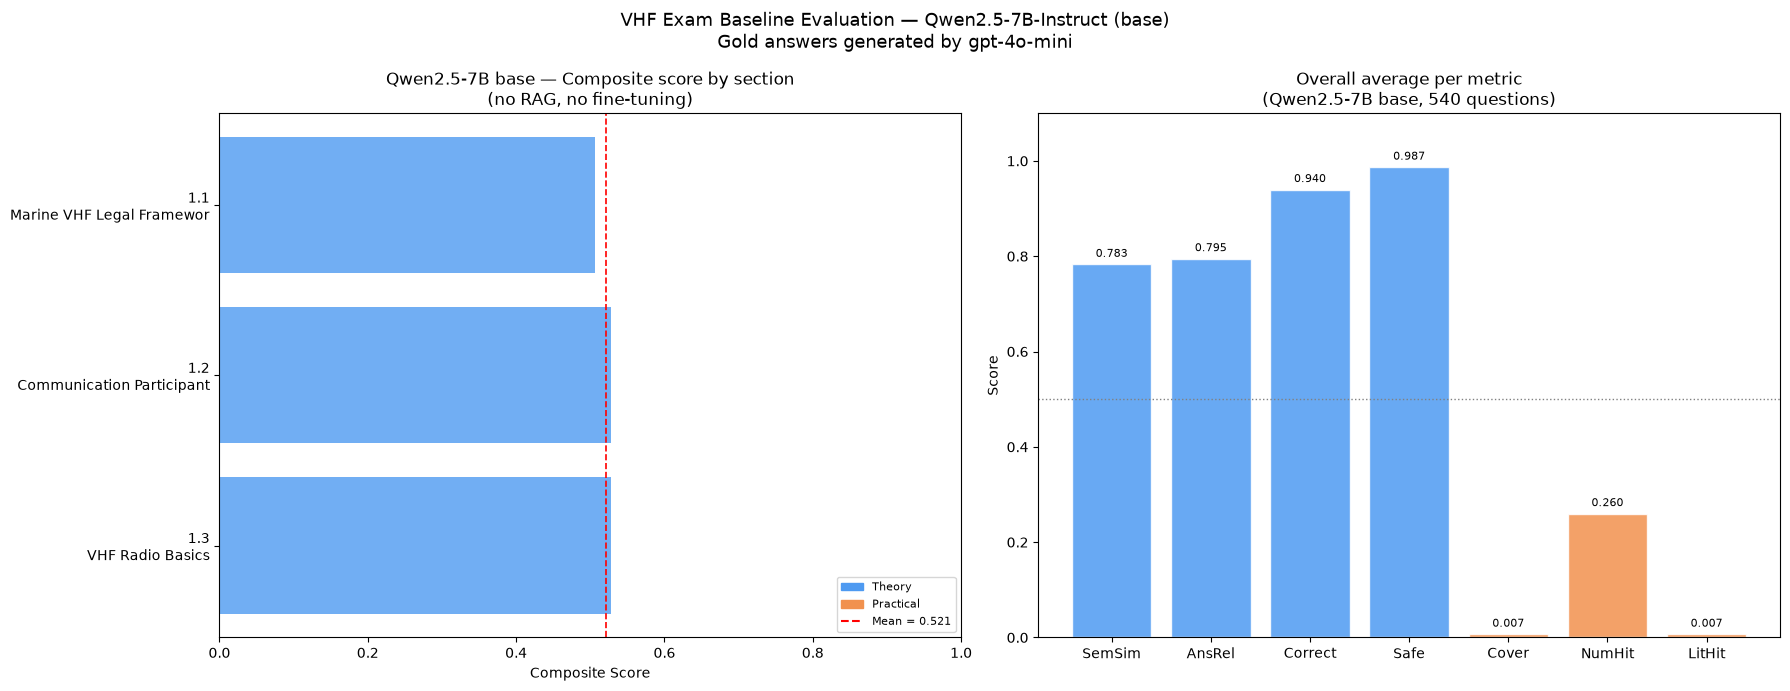

Plot saved to C:\Users\jcsch\Documents\Python\Auto Pilot\Data\VHF\VHF_Agents_Training\vhf_baseline_eval.png
Qwen unloaded — VRAM allocated: 0.09 GB


In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_plot = df_sections.copy()
df_plot["label"] = df_plot["section_id"] + "\n" + df_plot["section_title"].str[:25]
colors  = {"Theory": "#4e9af1", "Practical": "#f1914e"}

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

# ── Left: Composite per section ───────────────────────────────────────────
ax = axes[0]
for i, row in df_plot.iterrows():
    c = row.get("Composite")
    if c is None:
        continue
    ax.barh(row["label"], c, color=colors.get(row["type"], "#888"), alpha=0.8)

mean_comp = overall_means.get("Composite")
if mean_comp:
    ax.axvline(mean_comp, color="red", linestyle="--", linewidth=1.2,
               label=f"Overall mean = {mean_comp:.3f}")
ax.set_xlim(0, 1)
ax.set_xlabel("Composite Score")
ax.set_title("Qwen2.5-7B base — Composite score by section\n(no RAG, no fine-tuning)")
ax.invert_yaxis()
ax.legend(loc="lower right", fontsize=9)

# ── Right: All metrics overall ────────────────────────────────────────────
ax2 = axes[1]
metric_vals  = [(k, overall_means.get(k)) for k in METRIC_KEYS if k != "Composite"]
metric_vals  = [(k, v) for k, v in metric_vals if v is not None]
labels, vals = zip(*metric_vals) if metric_vals else ([], [])
bar_colors   = ["#4e9af1" if v and v >= 0.5 else "#f1914e" for v in vals]

bars = ax2.bar(labels, vals, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("Score")
ax2.set_title("Overall average per metric\n(Qwen2.5-7B base, 540 questions)")
ax2.axhline(0.5, color="grey", linestyle=":", linewidth=1)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
axes[0].legend(handles=legend_patches + [
    plt.Line2D([0], [0], color="red", linestyle="--", label=f"Mean = {mean_comp:.3f}")
], fontsize=8, loc="lower right")

fig.suptitle(
    "VHF Exam Baseline Evaluation — Qwen2.5-7B-Instruct (base)\n"
    f"Gold answers generated by {GOLD_MODEL}",
    fontsize=13
)
fig.tight_layout()
plt.savefig(CACHE_DIR / "vhf_baseline_eval.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved to {CACHE_DIR / 'vhf_baseline_eval.png'}")

# ── Unload Qwen from VRAM ─────────────────────────────────────────────────
# §§ 13-16 launch subprocesses that load their own Qwen (~5 GB VRAM). On an
# 8 GB laptop GPU we can't fit two copies, so we release the in-kernel model
# now that the baseline evaluation is done. Rerun § 5 later if you need
# in-kernel Qwen again.
try:
    _qwen_model = None
    _qwen_tok   = None
    import gc, torch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        alloc_gb = torch.cuda.memory_allocated() / 1024**3
        print(f"Qwen unloaded — VRAM allocated: {alloc_gb:.2f} GB")
except Exception as e:
    print(f"[cleanup] {e}")

---
## § 8 — Convert Source Documents to Structured JSON (foundational ontology)

Following Tutorial 13 § 3, we first transform every training source (26 files: 7 TXT/MD + 19 PDF) into a **hierarchical JSON schema**. This is the raw material for content-aware chunking downstream.

### Why not just chunk raw text?

Sliding-window chunkers cut through the middle of a MAYDAY procedure, split a definition from its term, or mix an SMCP example with an unrelated rule. Every RAG / KG-RAG / SFT / RLHF artifact built on such chunks inherits the structural damage.

Instead, the JSON here:
1. Preserves the **document hierarchy** (chapter → section)
2. Tags each section with a **type** (`rule` · `definition` · `procedure` · `example` · `warning` · `dialogue` · `reference`)
3. Extracts **concepts** (VHF terminology, channel numbers, pro-words, regulations)
4. Labels **topics** (channels · distress · GMDSS · phonetic · regulations · etc.)
5. Records **procedure steps** where applicable

Later, semantic chunkers respect these boundaries — a chunk never crosses a section, related sections may be combined up to a token budget, and each section retains its type/concepts/topics for downstream artifact generation.

### Output
- One JSON file per source document under `_json/`
- A summary index `_json/_index.json` with document counts, types, topics
- Documents that fail to parse are reported but do not stop the pipeline

In [21]:
import re, hashlib
from typing import Optional
from pathlib import Path

JSON_OUT_DIR = VHF_ROOT / "VHF_JSON"
JSON_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── § 8.1a  File → document classification ─────────────────────────────────
# Filename-based classification. Files below have hand-curated types/publishers.
# Anything in DATA_DIR that isn't listed gets auto-added at the bottom of this
# cell as ("reference", "Auto", "en") so newly-dropped-in documents flow through
# the rest of the pipeline without manual edits. Override entries here to give
# them a better source_type or publisher.
SOURCE_CLASSIFICATION: dict[str, Optional[tuple[str, str, str]]] = {
    # TXT / MD training sources — guides + protocols
    "BoatUS.txt":                         ("guide",       "BoatUS",              "en"),
    "CompleteGuideVHF.txt":               ("guide",       "Don Casey",           "en"),
    "MarinePublicVHF.txt":                ("guide",       "Public marine blog",  "en"),
    "NZC VHF.txt":                        ("protocol",    "North Sea Club",      "en"),
    "VHFPro.txt":                         ("guide",       "SMCP compendium",     "en"),
    "VHFProtocolsUS.txt":                 ("guide",       "Mathew F",            "en"),
    "VHF-procedures-Scheldt-area-EN.md":  ("protocol",    "GNA Scheldt",         "en"),

    # PDFs
    "Basic MAYDAY Call.pdf":                                                   ("procedure_card", "Reference",    "en"),
    "Calling the coastguard.pdf":                                              ("guide",          "Reference",    "en"),
    "CEPT Regulations.pdf":                                                    ("regulation",     "CEPT",         "en"),
    "Channel Listing.pdf":                                                     ("reference",      "ITU/CEPT",     "en"),
    "DSC alert flow chart.pdf":                                                ("procedure_card", "Reference",    "en"),
    "dg_185583-1.pdf":                                                         ("regulation",     "UK Gov",       "en"),
    "GMDSS VHF DSC procedures for small boat users - GOV.UK.pdf":              ("guide",          "MCA / GOV.UK", "en"),
    "IMO standard marine comms phrases.pdf":                                   ("regulation",     "IMO",          "en"),
    "mgn375.pdf":                                                              ("regulation",     "MCA",          "en"),
    "mgn_324.pdf":                                                             ("regulation",     "MCA",          "en"),
    "MSI.pdf":                                                                 ("protocol",       "Reference",    "en"),
    "msi_leaflet_2010_version.pdf":                                            ("reference",      "Reference",    "en"),
    "PHONETIC ALPHABET.pdf":                                                   ("reference",      "NATO/ICAO",    "en"),
    "R-REC-M.489-2-199510-I!!PDF-E.pdf":                                       ("regulation",     "ITU",          "en"),
    "Ship radio guidance for licencing.pdf":                                   ("regulation",     "Ofcom",        "en"),
    "Ship radio information ofcom.pdf":                                        ("guide",          "Ofcom",        "en"),
    "Ship radio licence application.pdf":                                      ("reference",      "Ofcom",        "en"),
    "VHF-Cheatsheet-v2.pdf":                                                   ("procedure_card", "Reference",    "en"),
    "VHF RADIO REGULATIONS.pdf":                                               ("regulation",     "Reference",    "en"),

    # Skipped (Dutch language)
    "NL-Marifoon-procedures-7.4.pdf": None,
}

def slug(text: str, max_len: int = 40) -> str:
    """URL-safe slug for IDs."""
    s = re.sub(r"[^a-z0-9]+", "_", (text or "").lower()).strip("_")
    return s[:max_len] or "section"

def stable_id(prefix: str, *parts: str) -> str:
    """Deterministic short ID from a prefix + content."""
    h = hashlib.md5(("|".join(str(p) for p in parts)).encode()).hexdigest()[:8]
    return f"{prefix}_{h}"


# ── § 8.1b  VHF concept vocabulary (drives extraction of `concepts`) ───────
VHF_CONCEPTS: dict[str, str] = {
    # Distress / urgency / safety
    "MAYDAY":            "distress",       "MAYDAY RELAY":     "distress",
    "PAN PAN":           "urgency",        "PAN PAN MEDICO":   "urgency",
    "SECURITE":          "safety",         "SÉCURITÉ":         "safety",
    "SEELONCE MAYDAY":   "distress",       "SEELONCE FEENEE":  "distress",
    "PRUDONCE":          "distress",       "SEELONCE DISTRESS":"distress",

    # Pro-words
    "OVER":  "prowords", "OUT":   "prowords", "ROGER": "prowords", "WILCO": "prowords",
    "SAY AGAIN": "prowords", "I SPELL": "prowords", "STANDBY": "prowords",
    "CORRECTION": "prowords", "BREAK": "prowords", "ALL STATIONS": "prowords",
    "AFFIRMATIVE": "prowords", "NEGATIVE": "prowords", "THIS IS": "prowords",
    "I SAY AGAIN": "prowords", "WAIT OUT": "prowords",

    # Channels
    "Channel 6":  "channels", "Channel 8":  "channels", "Channel 9":  "channels",
    "Channel 12": "channels", "Channel 13": "channels", "Channel 14": "channels",
    "Channel 16": "channels", "Channel 22A":"channels", "Channel 67": "channels",
    "Channel 70": "channels", "Channel 72": "channels", "Channel 77": "channels",
    "Channel 80": "channels", "Channel 88": "channels",
    "156.800 MHz": "channels", "156.525 MHz": "channels",

    # GMDSS / equipment
    "DSC": "gmdss", "GMDSS": "gmdss", "EPIRB": "gmdss", "SART": "gmdss",
    "AIS-SART": "gmdss", "NAVTEX": "gmdss", "Inmarsat": "gmdss",
    "MMSI": "gmdss", "MRCC": "gmdss", "SAR": "gmdss",
    "Sea Area A1": "gmdss", "Sea Area A2": "gmdss",
    "Sea Area A3": "gmdss", "Sea Area A4": "gmdss",
    "MSI": "gmdss", "AIS": "gmdss",

    # Regulations / bodies
    "ITU Radio Regulations": "regulation", "SOLAS": "regulation",
    "CEPT": "regulation", "Ofcom": "regulation", "MCA": "regulation",
    "IMO": "regulation", "SMCP": "regulation", "SRC": "regulation",
    "ROC": "regulation", "GOC": "regulation",
    "Ship Station Licence": "regulation", "Cospas-Sarsat": "regulation",

    # Phonetic alphabet (subset — parser also detects the full alphabet elsewhere)
    "ALFA": "phonetic", "BRAVO": "phonetic", "CHARLIE": "phonetic",
    "DELTA": "phonetic", "ECHO": "phonetic", "FOXTROT": "phonetic",
    "PAPA": "phonetic", "TANGO": "phonetic", "YANKEE": "phonetic",
    "ZULU": "phonetic",

    # Radio basics
    "VHF": "basics", "simplex": "basics", "duplex": "basics",
    "squelch": "basics", "PTT": "basics", "watchkeeping": "basics",
    "line-of-sight": "basics",
}

_CONCEPT_PATTERNS = [
    (re.compile(rf"\b{re.escape(k)}\b", re.IGNORECASE), k, v)
    for k, v in VHF_CONCEPTS.items()
]

def extract_concepts(text: str) -> tuple[list[str], list[str]]:
    """Return (concepts, topics) found in text using the VHF vocabulary."""
    if not text:
        return [], []
    found_concepts = []
    found_topics   = set()
    seen           = set()
    for pattern, key, topic in _CONCEPT_PATTERNS:
        if pattern.search(text) and key.lower() not in seen:
            seen.add(key.lower())
            found_concepts.append(key)
            found_topics.add(topic)
    return found_concepts, sorted(found_topics)


# ── § 8.1c  Section type classifier (rule-based, fast, good enough) ────────
_TYPE_RULES = [
    ("procedure",  re.compile(r"\b(step\s+\d|first,?|second,?|then\s+|finally,?|"
                              r"press\s+PTT|switch\s+to\s+channel|tune\s+to\s+channel|"
                              r"1\.\s|2\.\s|3\.\s|1️⃣|►|•\s+[A-Z])", re.IGNORECASE)),
    ("rule",       re.compile(r"\b(must|shall\s+not|shall\s+|is\s+required|"
                              r"is\s+prohibited|is\s+forbidden|never\s+use|"
                              r"only\s+authorised|only\s+authorized)\b", re.IGNORECASE)),
    ("definition", re.compile(r"\b(is\s+defined\s+as|refers\s+to|means\s+the|"
                              r"is\s+a\s+(term|word|signal|acronym)|"
                              r"stands\s+for|is\s+the\s+abbreviation)\b", re.IGNORECASE)),
    ("warning",    re.compile(r"\b(warning|caution|danger|do\s+not|avoid|"
                              r"never\s+transmit)\b", re.IGNORECASE)),
    ("dialogue",   re.compile(r'\"(?:MAYDAY|PAN PAN|THIS IS|OVER|OUT)|'
                              r'^(Vessel|Coastguard|Marina|Port Control)[\s\:]', re.MULTILINE | re.IGNORECASE)),
    ("example",    re.compile(r"\b(example|for\s+instance|e\.g\.|such\s+as)\b", re.IGNORECASE)),
]

def classify_section(text: str) -> str:
    """Return the best-fit section type from the rules above."""
    if not text:
        return "reference"
    for stype, pattern in _TYPE_RULES:
        if pattern.search(text):
            return stype
    return "reference"


# ── § 8.1d  Step extractor (for type=procedure) ────────────────────────────
_STEP_PATTERNS = [
    re.compile(r"^\s*\d+[\.\)]\s+(.+)$",         re.MULTILINE),
    re.compile(r"^\s*[1-9]️⃣\s*(.+)$",           re.MULTILINE),
    re.compile(r"^Step\s+\d+\s*[:\-]?\s*(.+)$",  re.MULTILINE | re.IGNORECASE),
    re.compile(r"^\s*[►•\-*]\s+(.+)$",           re.MULTILINE),
]

def extract_steps(text: str) -> list[str]:
    """Pull step-like lines out of a paragraph; empty list if none found."""
    if not text:
        return []
    steps: list[str] = []
    for pattern in _STEP_PATTERNS:
        found = [m.group(1).strip() for m in pattern.finditer(text) if m.group(1).strip()]
        if len(found) >= 2:
            steps = found
            break
    return steps


# ── § 8.1e  Empty document skeleton ────────────────────────────────────────
def new_document(source_file: str) -> dict:
    info = SOURCE_CLASSIFICATION.get(source_file)
    if info is None:
        return {}
    doc_type, publisher, lang = info
    return {
        "document_id":  slug(Path(source_file).stem),
        "source_file":  source_file,
        "source_type":  doc_type,
        "publisher":    publisher,
        "language":     lang,
        "chapters":     [],
        "parsing_notes": [],
        "metadata":     {
            "total_words":     0,
            "total_sections":  0,
            "primary_topics":  [],
        },
    }


# ── § 8.1f  Auto-discover new source files added under DATA_DIR ────────────
# Files with .txt / .md / .pdf that aren't yet listed above get an "Auto" entry
# so § 8.4 will convert them and everything downstream will pick them up.
_DATA_EXTS = {".txt", ".md", ".pdf"}
_present   = {p.name for p in DATA_DIR.iterdir()
              if p.is_file() and p.suffix.lower() in _DATA_EXTS}
_unknown   = sorted(_present - set(SOURCE_CLASSIFICATION.keys()))
for _name in _unknown:
    SOURCE_CLASSIFICATION[_name] = ("reference", "Auto", "en")

print("Schema, classifiers and helpers defined.")
print(f"  VHF concepts     : {len(VHF_CONCEPTS)}  ·  type rules: {len(_TYPE_RULES)}")
print(f"  Output dir       : {JSON_OUT_DIR}")
print(f"  Classified files : {sum(1 for v in SOURCE_CLASSIFICATION.values() if v is not None)}"
      f"  (of which {len(_unknown)} auto-added)")
if _unknown:
    print(f"\n  New files auto-added as ('reference','Auto','en'):")
    for _n in _unknown:
        print(f"    + {_n}")
    print(f"  Edit SOURCE_CLASSIFICATION above to give them a better source_type/publisher.")

Schema, classifiers and helpers defined.
  VHF concepts     : 86  ·  type rules: 6
  Output dir       : C:\Users\jcsch\Documents\Python\Auto Pilot\Data\VHF\VHF_JSON
  Classified files : 40  (of which 14 auto-added)

  New files auto-added as ('reference','Auto','en'):
    + 36_VHF_Exchanges.pdf
    + 36a-makingcontact.pdf
    + 5CVHF.txt
    + CS Part 3-4 - General VHF Radio Procedure - March 2025.pdf
    + Essential_Guide_VHF.txt
    + ProWords Scenario Test Answers.pdf
    + ProWords Scenario Test.pdf
    + SailingBlogVHF.txt
    + Talk_Like_Old_Salt.txt
    + VHF-Radio-Messages-Sample.pdf
    + VHFIMOSummaries.txt
    + VHF_Radio_Etiquette.txt
    + marine_vhf_radio_sample_pages.pdf
    + notice-proper-use-of-vhf-sb3-25.pdf
  Edit SOURCE_CLASSIFICATION above to give them a better source_type/publisher.


### § 8.2 — Convert TXT / MD sources to JSON

Each text file has a different heading style. The generic parser:
1. Splits the file into candidate blocks on blank lines
2. Detects heading vs paragraph by heuristics (length, capitalisation, markdown `#`, no terminal punctuation)
3. Groups paragraphs under the most recent heading

Falls back to a single "Body" section if no headings are detected.

In [22]:
import re
from typing import Optional

# ── Heading detection ──────────────────────────────────────────────────────
_STOP_WORDS_LEAD = {
    "the", "a", "an", "this", "that", "these", "those", "i", "we", "you",
    "he", "she", "it", "they", "in", "on", "at", "for", "with", "by", "as",
    "if", "when", "where", "how", "why", "what", "however", "moreover",
    "therefore", "thus", "some", "many", "few", "most", "all", "every",
    "before", "after", "during", "under", "over", "between",
}

_NUMBERED_HEADING_RE = re.compile(r"^(\d+(?:\.\d+)*)\s+([A-Z].+)$")

def detect_heading(line: str) -> Optional[tuple[int, str]]:
    """Return (level 1-3, cleaned title) if `line` looks like a heading, else None."""
    stripped = line.strip()
    if not stripped or len(stripped) > 120:
        return None

    # Markdown ##
    m = re.match(r"^(#{1,6})\s+(.+?)\s*$", stripped)
    if m:
        return (min(len(m.group(1)), 3), m.group(2).strip())

    # Numbered "1. Foo" / "2.3 Bar"
    m = _NUMBERED_HEADING_RE.match(stripped)
    if m and not stripped.endswith((".", ":", "?", "!", ",", ";")):
        level = min(stripped.count(".") + 1, 3)
        return (level, stripped)

    words = stripped.split()
    n_words = len(words)
    if n_words < 2 or n_words > 12:
        return None
    if stripped.endswith((".", ":", "?", "!", ",", ";", "…")):
        return None
    if stripped[0].islower():
        return None
    if words[0].lower() in _STOP_WORDS_LEAD:
        return None

    # ALL CAPS heading (level 1)
    if stripped == stripped.upper() and stripped[0].isalpha():
        return (1, stripped.title())

    # Title case heading (level 2)
    n_cap = sum(1 for w in words if w and (w[0].isupper() or w[0].isdigit()))
    if n_cap / n_words >= 0.6:
        return (2, stripped)

    return None


# ── TXT / MD → JSON ────────────────────────────────────────────────────────
def parse_txt_file(path: Path) -> dict:
    """Convert one TXT or MD file into the hierarchical JSON schema."""
    doc = new_document(path.name)
    if not doc:
        return {}

    raw   = path.read_text(encoding="utf-8", errors="replace").replace("\r\n", "\n")
    lines = raw.split("\n")

    chapters: list[dict] = []
    current_chapter: Optional[dict] = None
    pending_section_title: Optional[str] = None
    buffer: list[str] = []

    def start_chapter(title: str) -> None:
        nonlocal current_chapter
        if current_chapter is not None:
            chapters.append(current_chapter)
        current_chapter = {
            "chapter_id": stable_id("c", doc["document_id"], len(chapters), title),
            "title":      title,
            "level":      1,
            "sections":   [],
        }

    def flush_paragraph_to_section() -> None:
        nonlocal buffer, pending_section_title, current_chapter
        text = "\n\n".join(b.strip() for b in "\n".join(buffer).split("\n\n") if b.strip()).strip()
        buffer = []
        if not text:
            pending_section_title = None
            return
        if current_chapter is None:
            start_chapter(doc["document_id"])
        concepts, topics = extract_concepts(text)
        sec_type = classify_section(text)
        steps    = extract_steps(text) if sec_type == "procedure" else []
        title    = pending_section_title or (text.split("\n", 1)[0][:60].rstrip(":.") or "Body")
        current_chapter["sections"].append({
            "section_id": stable_id("s", doc["document_id"], sum(len(c["sections"]) for c in chapters) + len(current_chapter["sections"]), title),
            "title":      title,
            "level":      2,
            "type":       sec_type,
            "text":       text,
            "concepts":   concepts,
            "topics":     topics,
            "steps":      steps,
        })
        pending_section_title = None

    for line in lines:
        heading = detect_heading(line)
        if heading is None:
            buffer.append(line)
            continue
        level, title = heading
        flush_paragraph_to_section()
        if level == 1:
            start_chapter(title)
        else:
            if current_chapter is None:
                start_chapter(doc["document_id"])
            pending_section_title = title

    flush_paragraph_to_section()
    if current_chapter is not None:
        chapters.append(current_chapter)

    # Fallback: single section for the whole document
    if not chapters:
        body = raw.strip()
        concepts, topics = extract_concepts(body)
        chapters = [{
            "chapter_id": stable_id("c", doc["document_id"], 0),
            "title":      path.stem,
            "level":      1,
            "sections":  [{
                "section_id": stable_id("s", doc["document_id"], 0),
                "title":      "Body",
                "level":      2,
                "type":       classify_section(body),
                "text":       body,
                "concepts":   concepts,
                "topics":     topics,
                "steps":      [],
            }],
        }]

    doc["chapters"] = chapters
    all_topics: set[str] = set()
    n_sections = 0
    n_words    = 0
    for ch in chapters:
        for s in ch["sections"]:
            all_topics.update(s.get("topics", []))
            n_sections += 1
            n_words    += len(s.get("text", "").split())
    doc["metadata"]["primary_topics"] = sorted(all_topics)
    doc["metadata"]["total_sections"] = n_sections
    doc["metadata"]["total_words"]    = n_words
    return doc


# ── Quick self-test on one file so we see the output shape ─────────────────
_sample_txt = DATA_DIR / "BoatUS.txt"
if _sample_txt.exists():
    _sample_doc = parse_txt_file(_sample_txt)
    print(f"Parsed {_sample_txt.name}:")
    print(f"  chapters       : {len(_sample_doc['chapters'])}")
    print(f"  total sections : {_sample_doc['metadata']['total_sections']}")
    print(f"  total words    : {_sample_doc['metadata']['total_words']}")
    print(f"  primary topics : {_sample_doc['metadata']['primary_topics']}")
    print(f"\nFirst chapter: {_sample_doc['chapters'][0]['title']!r}")
    for s in _sample_doc['chapters'][0]['sections'][:2]:
        print(f"  section {s['section_id']}  type={s['type']}  concepts={s['concepts'][:5]}")
        print(f"    title: {s['title']}")
        print(f"    text : {s['text'][:120]}...")


Parsed BoatUS.txt:
  chapters       : 2
  total sections : 3
  total words    : 910
  primary topics : ['basics', 'channels', 'distress', 'gmdss', 'prowords']

First chapter: 'boatus'
  section s_45e2f422  type=reference  concepts=['VHF']
    title: Many boaters never take the time to learn how to properly us
    text : Many boaters never take the time to learn how to properly use one of the most important pieces of safety gear on board y...
  section s_89e318be  type=example  concepts=['OVER', 'OUT', 'Channel 9', 'Channel 13', 'Channel 16']
    title: Know Thy Channel
    text : Rule No. 1: Respect the channel designations, especially those of the "big three." Channel 16 is reserved for distress a...


### § 8.3 — Convert PDF sources to JSON

Uses `pdfplumber` to extract text + font metadata per line. Headings are detected by:
1. **Font size** — lines with above-median font size on the page
2. **Bold weight** — font names ending in `Bold` / `-B`
3. **Pattern** — numbered headings (`1.`, `2.3`) or ALL CAPS short lines

For scanned PDFs (image-only, no text layer) `pdfplumber` returns empty pages — we detect this and set `parsing_notes: ["scanned_pdf_ocr_needed"]` so we can add OCR later if needed.

In [23]:
import pdfplumber
import statistics

# ── Per-page line extraction with font metadata ────────────────────────────
def _extract_lines_with_meta(page) -> list[dict]:
    """Extract text lines with median font size and bold flag."""
    chars = page.chars
    if not chars:
        return []
    lines: dict[int, list[dict]] = {}
    for ch in chars:
        y = int(round(ch["top"]))
        lines.setdefault(y, []).append(ch)
    out = []
    for y in sorted(lines):
        chs = sorted(lines[y], key=lambda c: c["x0"])
        text = "".join(c["text"] for c in chs).strip()
        if not text:
            continue
        sizes = [c["size"] for c in chs]
        fonts = [c.get("fontname", "") for c in chs]
        median_size = statistics.median(sizes) if sizes else 0.0
        is_bold = any(re.search(r"Bold|-B\b|,B\b", f) for f in fonts)
        out.append({"text": text, "size": median_size, "bold": is_bold, "y": y})
    return out


def _is_pdf_heading(line: dict, page_median_size: float) -> Optional[int]:
    """Return a heading level (1|2) if this line looks like a heading, else None."""
    text = line["text"].strip()
    if not text or len(text) > 120:
        return None

    words = text.split()
    if len(words) < 2 or len(words) > 14:
        return None
    if text.endswith((".", ";", ",", "…")):
        return None

    # 1. Larger-than-body font  →  strong heading signal
    size = line.get("size", 0.0)
    if size >= page_median_size * 1.20:
        return 1 if size >= page_median_size * 1.40 else 2

    # 2. Bold + short  →  level-2 heading
    if line.get("bold") and 2 <= len(words) <= 10:
        return 2

    # 3. Text-based heuristics fallback (same rules as TXT)
    heading = detect_heading(text)
    return heading[0] if heading else None


# ── PDF → JSON ─────────────────────────────────────────────────────────────
def parse_pdf_file(path: Path, max_pages: int = 200) -> dict:
    doc = new_document(path.name)
    if not doc:
        return {}

    all_lines: list[dict] = []
    empty_pages = 0

    try:
        with pdfplumber.open(str(path)) as pdf:
            n_pages = min(len(pdf.pages), max_pages)
            for i in range(n_pages):
                lines = _extract_lines_with_meta(pdf.pages[i])
                if not lines:
                    empty_pages += 1
                    continue
                # Attach page number for provenance
                for ln in lines:
                    ln["page"] = i + 1
                all_lines.extend(lines)
    except Exception as e:
        doc["parsing_notes"].append(f"pdfplumber_error: {e.__class__.__name__}: {e}")
        return doc

    if not all_lines:
        doc["parsing_notes"].append("scanned_pdf_ocr_needed")
        return doc

    if empty_pages:
        doc["parsing_notes"].append(f"empty_pages: {empty_pages}")

    # Median font size across the whole document — used as body-text reference
    doc_median_size = statistics.median(l["size"] for l in all_lines) or 10.0

    chapters: list[dict] = []
    current_chapter: Optional[dict] = None
    pending_section_title: Optional[str] = None
    buffer_texts: list[str] = []
    buffer_pages: list[int] = []

    def start_chapter(title: str) -> None:
        nonlocal current_chapter
        if current_chapter is not None:
            chapters.append(current_chapter)
        current_chapter = {
            "chapter_id": stable_id("c", doc["document_id"], len(chapters), title),
            "title":      title,
            "level":      1,
            "sections":   [],
        }

    def flush_section() -> None:
        nonlocal buffer_texts, buffer_pages, pending_section_title, current_chapter
        body = " ".join(buffer_texts).strip()
        buffer_texts = []
        pages = sorted(set(buffer_pages))
        buffer_pages = []
        if not body:
            pending_section_title = None
            return
        if current_chapter is None:
            start_chapter(doc["document_id"])
        concepts, topics = extract_concepts(body)
        sec_type = classify_section(body)
        steps    = extract_steps(body) if sec_type == "procedure" else []
        title    = pending_section_title or body.split(".")[0][:80].strip() or "Body"
        current_chapter["sections"].append({
            "section_id": stable_id("s", doc["document_id"], sum(len(c["sections"]) for c in chapters) + len(current_chapter["sections"]), title),
            "title":      title,
            "level":      2,
            "type":       sec_type,
            "text":       body,
            "concepts":   concepts,
            "topics":     topics,
            "steps":      steps,
            "pages":      pages,
        })
        pending_section_title = None

    for ln in all_lines:
        h_level = _is_pdf_heading(ln, doc_median_size)
        text    = ln["text"].strip()
        if h_level is None:
            buffer_texts.append(text)
            buffer_pages.append(ln.get("page", 0))
            continue
        flush_section()
        title = re.sub(r"^\s*[\d.]+\s+", lambda m: m.group(0) + "", text)  # keep number prefix
        if h_level == 1:
            start_chapter(text)
        else:
            if current_chapter is None:
                start_chapter(doc["document_id"])
            pending_section_title = text

    flush_section()
    if current_chapter is not None:
        chapters.append(current_chapter)

    # Fallback for flat PDFs with no detectable headings (cheatsheets, cards)
    if not chapters or all(not c["sections"] for c in chapters):
        body = " ".join(l["text"] for l in all_lines).strip()
        if body:
            concepts, topics = extract_concepts(body)
            chapters = [{
                "chapter_id": stable_id("c", doc["document_id"], 0),
                "title":      path.stem,
                "level":      1,
                "sections":  [{
                    "section_id": stable_id("s", doc["document_id"], 0),
                    "title":      "Body",
                    "level":      2,
                    "type":       classify_section(body),
                    "text":       body,
                    "concepts":   concepts,
                    "topics":     topics,
                    "steps":      [],
                    "pages":      sorted(set(l.get("page", 0) for l in all_lines)),
                }],
            }]
            doc["parsing_notes"].append("flat_document_no_headings_detected")

    doc["chapters"] = chapters
    all_topics: set[str] = set()
    n_sections = 0
    n_words    = 0
    for ch in chapters:
        for s in ch["sections"]:
            all_topics.update(s.get("topics", []))
            n_sections += 1
            n_words    += len(s.get("text", "").split())
    doc["metadata"]["primary_topics"] = sorted(all_topics)
    doc["metadata"]["total_sections"] = n_sections
    doc["metadata"]["total_words"]    = n_words
    doc["metadata"]["total_pages"]    = max((l.get("page", 0) for l in all_lines), default=0)
    return doc


# ── Quick self-test on one small PDF ────────────────────────────────────────
_sample_pdf = DATA_DIR / "PHONETIC ALPHABET.pdf"
if _sample_pdf.exists():
    _sample_doc = parse_pdf_file(_sample_pdf)
    print(f"Parsed {_sample_pdf.name}:")
    print(f"  chapters       : {len(_sample_doc.get('chapters', []))}")
    print(f"  sections       : {_sample_doc.get('metadata', {}).get('total_sections')}")
    print(f"  words          : {_sample_doc.get('metadata', {}).get('total_words')}")
    print(f"  pages          : {_sample_doc.get('metadata', {}).get('total_pages')}")
    print(f"  parsing_notes  : {_sample_doc.get('parsing_notes')}")
    print(f"  primary topics : {_sample_doc.get('metadata', {}).get('primary_topics')}")


Parsed PHONETIC ALPHABET.pdf:
  chapters       : 1
  sections       : 1
  words          : 1
  pages          : 1
  parsing_notes  : []
  primary topics : []


### § 8.4 — Run all documents + build index

Parses every source file (7 TXT/MD + 19 PDF = 26 documents), writes one JSON per file to `_json/`, and writes a summary index `_json/_index.json`.

Cached on disk — re-running is free unless you delete `_json/`.

In [24]:
from tqdm.auto import tqdm
import pandas as pd

INDEX_FILE = JSON_OUT_DIR / "_index.json"


def _sources_missing_jsons() -> list[str]:
    """Classified sources that don't yet have a JSON in _json/."""
    missing = []
    for name, cls in SOURCE_CLASSIFICATION.items():
        if cls is None:
            continue
        if not (DATA_DIR / name).exists():
            continue
        if not (JSON_OUT_DIR / f"{Path(name).stem}.json").exists():
            missing.append(name)
    return missing


def convert_all_sources(force: bool = False) -> list[dict]:
    """Convert every configured source into JSON under _json/. Return the index.

    Fast-path: if `_index.json` exists AND every classified source has its JSON,
    just load the index. Any missing JSON (typically a newly-added source) drops
    us into the full loop so the new file gets processed.
    """
    missing = _sources_missing_jsons()

    if INDEX_FILE.exists() and not force and not missing:
        cached = json.loads(INDEX_FILE.read_text(encoding="utf-8"))
        docs = cached.get("documents", [])
        if docs:
            print(f"Using cached _json/ index ({len(docs)} documents on disk).")
            return docs

    if missing:
        print(f"Detected {len(missing)} new source file(s) without a JSON — running conversion.")
        for m in missing[:10]:
            print(f"  new: {m}")

    index: list[dict] = []
    skipped: list[str] = []

    todo = [(name, cls) for name, cls in SOURCE_CLASSIFICATION.items() if cls is not None]

    for name in tqdm(sorted(dict(todo).keys()), desc="Documents"):
        src = DATA_DIR / name
        if not src.exists():
            skipped.append(f"{name} (file not found)")
            continue

        out_path = JSON_OUT_DIR / f"{Path(name).stem}.json"
        if out_path.exists() and not force:
            doc = json.loads(out_path.read_text(encoding="utf-8"))
        else:
            try:
                if src.suffix.lower() in {".txt", ".md"}:
                    doc = parse_txt_file(src)
                elif src.suffix.lower() == ".pdf":
                    doc = parse_pdf_file(src)
                else:
                    skipped.append(f"{name} (unsupported extension)")
                    continue
            except Exception as e:
                skipped.append(f"{name} ({e.__class__.__name__}: {e})")
                continue
            if not doc:
                skipped.append(f"{name} (empty result)")
                continue
            out_path.write_text(
                json.dumps(doc, indent=2, ensure_ascii=False), encoding="utf-8"
            )

        index.append({
            "source_file":    doc["source_file"],
            "document_id":    doc["document_id"],
            "source_type":    doc["source_type"],
            "publisher":      doc["publisher"],
            "language":       doc["language"],
            "chapters":       len(doc["chapters"]),
            "sections":       doc["metadata"]["total_sections"],
            "words":          doc["metadata"]["total_words"],
            "primary_topics": doc["metadata"]["primary_topics"],
            "parsing_notes":  doc.get("parsing_notes", []),
        })

    INDEX_FILE.write_text(
        json.dumps({"documents": index, "skipped": skipped}, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    return index


index = convert_all_sources(force=False)

# ── Report ────────────────────────────────────────────────────────────────
df_idx = pd.DataFrame(index)
if df_idx.empty:
    print("No documents processed.")
else:
    df_display = df_idx[["source_file", "source_type", "chapters", "sections", "words", "parsing_notes"]].copy()
    df_display["parsing_notes"] = df_display["parsing_notes"].apply(
        lambda x: ", ".join(x)[:60] if x else ""
    )

    print("\n" + "═" * 110)
    print(f"  {len(df_idx)} source documents in _json/")
    print("═" * 110)
    with pd.option_context("display.max_colwidth", 60, "display.width", 200):
        print(df_display.to_string(index=False))
    print("─" * 110)
    print(f"  Total sections : {df_idx['sections'].sum()}")
    print(f"  Total words    : {df_idx['words'].sum():,}")
    print(f"  Documents by type:")
    for t, n in df_idx["source_type"].value_counts().items():
        print(f"    {t:<18} {n:>3}")

    all_topics: set[str] = set()
    for topics in df_idx["primary_topics"]:
        all_topics.update(topics)
    print(f"  Distinct topics  : {sorted(all_topics)}")

Using cached _json/ index (40 documents on disk).

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  40 source documents in _json/
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                               source_file    source_type  chapters  sections  words  parsing_notes
                                      36_VHF_Exchanges.pdf      reference         7        33   1802               
                                     36a-makingcontact.pdf      reference         3        25    705 empty_pages: 1
                                                 5CVHF.txt      reference         1         2   1815               
                                     Basic MAYDAY Call.pdf procedure_card         1         1     12               
                                                BoatUS.txt          guide         2         3    910               

### § 8.5 — Sample inspection

Look at a few converted documents to judge extraction quality before moving on to RAG / KG / SFT.

In [ ]:
def peek(doc_id: str, max_sections: int = 4) -> None:
    """Pretty-print a few sections from one converted document."""
    path = JSON_OUT_DIR / f"{doc_id}.json"
    if not path.exists():
        print(f"Not found: {path}")
        return
    d = json.loads(path.read_text(encoding="utf-8"))
    print("═" * 100)
    print(f"  {d['source_file']}  ·  type={d['source_type']}  ·  publisher={d['publisher']}")
    print(f"  chapters={len(d['chapters'])}  sections={d['metadata']['total_sections']}  words={d['metadata']['total_words']}")
    print(f"  primary_topics: {d['metadata']['primary_topics']}")
    print("═" * 100)
    shown = 0
    for ch in d["chapters"]:
        if shown >= max_sections:
            break
        print(f"\n📖  Chapter: {ch['title']}")
        for s in ch["sections"]:
            if shown >= max_sections:
                break
            shown += 1
            print(f"\n  §  [{s['type']:<10}]  {s['title'][:80]}")
            print(f"     concepts : {s['concepts'][:6]}")
            print(f"     topics   : {s['topics']}")
            if s.get("steps"):
                print(f"     steps    : {len(s['steps'])} extracted")
            print(f"     text     : {s['text'][:200]}...")

# Show three contrasting samples
peek("VHF-procedures-Scheldt-area-EN")   # clean markdown
print()
peek("Basic MAYDAY Call")                # procedure card PDF (JSON keeps original spaces)
print()
peek("VHFPro")                           # SMCP guide TXT

════════════════════════════════════════════════════════════════════════════════════════════════════
  VHF-procedures-Scheldt-area-EN.md  ·  type=protocol  ·  publisher=GNA Scheldt
  chapters=1  sections=56  words=5995
  primary_topics: ['basics', 'channels', 'phonetic', 'prowords', 'regulation']
════════════════════════════════════════════════════════════════════════════════════════════════════

📖  Chapter: VHF PROCEDURES

  §  [reference ]  For safe and efficient shipping traffic in the Scheldt are
     concepts : []
     topics   : []
     text     : **For safe and efficient shipping traffic in the Scheldt area**...

  §  [definition]  FOREWORD
     concepts : ['IMO', 'VHF']
     topics   : ['basics', 'regulation']
     text     : These VHF procedures are a guideline for traffic controllers and traffic participants in the Scheldt area. Their aim is to clarify the use of VHF for safe and smooth shipping traffic. By correctly app...

  §  [procedure ]  2. Purpose of a Vessel Traffic S

### § 8.6 — OCR pass for scanned PDFs

One remaining training PDF has no text layer:
- `DSC alert flow chart.pdf`  (previously OCR'ed once; ~130 words captured)

Two other scanned PDFs (`Seamanship-Centre-…` and `VHF quiz ball.pdf`) live in `Data/VHF_Eval/` and are held out of the training pipeline entirely.

OCR is disabled by default. The one OCR'ed JSON already on disk is kept; nothing is re-rendered.  
To force a fresh OCR pass, flip `RUN_OCR = True` in the cell below and re-add the `ocr_pdf()` / `parse_ocr_text()` implementation (see git history commit `d8d0050`).

In [26]:
# Only the training PDFs are scanned candidates. The eval PDFs live in
# Data/VHF_Eval/ and are never touched by this loop.
SCANNED_PDFS = [
    "DSC alert flow chart.pdf",
]

RUN_OCR = False   # see § 8.6 markdown for how to re-enable

print(f"OCR pass — RUN_OCR={RUN_OCR}")
for name in SCANNED_PDFS:
    out = JSON_OUT_DIR / f"{Path(name).stem}.json"
    if out.exists():
        d = json.loads(out.read_text(encoding="utf-8"))
        words = d.get("metadata", {}).get("total_words", 0)
        print(f"  [skip] {name}  ->  {out.name}  ({words} words on disk)")
    else:
        print(f"  [skip] {name}  ->  no JSON yet")

if RUN_OCR:
    raise NotImplementedError(
        "OCR path was removed from the notebook to keep the runtime lean. "
        "See git history commit d8d0050 for ocr_pdf() + parse_ocr_text()."
    )

OCR pass — RUN_OCR=False
  [skip] DSC alert flow chart.pdf  ->  DSC alert flow chart.json  (131 words on disk)


### § 8.7 — Cleanup pass

Post-processes every JSON in `_json/` in place:

1. **Titles** — strip markdown (`**`, `_`, `#`), leading/trailing quotes, sentence-terminal punctuation
2. **Better dialogue detection** — sections with speaker labels or multiple quoted VHF phrases → `type: dialogue`
3. **Better definition detection** — `X is …` or `X = …` glossary patterns at start of section → `type: definition`
4. **Step normalisation** — strip leading numbering (`1.`, `►`, `•`) from extracted steps
5. **Empty / boilerplate section filtering** — sections with <4 words or that repeat the chapter title get merged into the next section

In [27]:
from collections import Counter

# ── Cleanup helpers ────────────────────────────────────────────────────────
_TITLE_TRIM_RE = re.compile(r"^[\s\*_#`\"'>\-]+|[\s\*_#`\"',.]+$")
_MULTI_WHITESPACE = re.compile(r"\s+")

def clean_title(t: str) -> str:
    if not t:
        return ""
    t = _TITLE_TRIM_RE.sub("", t)
    t = _MULTI_WHITESPACE.sub(" ", t).strip()
    words = t.split()
    if len(words) > 12:
        t = " ".join(words[:8]).rstrip(",;:") + "…"
    return t


_SPEAKER_RE = re.compile(
    r"^\s*(Vessel|Coastguard|Marina|Port\s+Control|MV\s|SV\s|MY\s|Harbour|"
    r"Bridge|SAR|MRCC|Skipper|Pilot|Operator|Master|Radio)\s*[:\-]",
    re.MULTILINE | re.IGNORECASE,
)
_VHF_QUOTE_RE = re.compile(
    r'\"[^\"]*(MAYDAY|PAN PAN|SÉCURITÉ|SECURITE|THIS IS|OVER|OUT|ROGER|WILCO|CHANNEL)[^\"]*\"',
    re.IGNORECASE,
)


def is_dialogue(text: str) -> bool:
    if not text:
        return False
    if _SPEAKER_RE.search(text):
        return True
    return len(_VHF_QUOTE_RE.findall(text)) >= 2


_DEFINITION_HEAD_RE = re.compile(
    r"^\s*([A-Z][A-Za-z0-9 \-]{1,30})\s*(?:is|are|means|refers to|stands for|=|:)\s+"
)


def is_definition(text: str) -> bool:
    if not text:
        return False
    first = text.split("\n", 1)[0]
    return bool(_DEFINITION_HEAD_RE.match(first))


def classify_section_v2(text: str, prev_type: str) -> str:
    """Improved classifier: prefer more specific types over 'reference'."""
    if not text:
        return "reference"
    if is_dialogue(text):
        return "dialogue"
    if is_definition(text):
        return "definition"
    return classify_section(text)


_STEP_PREFIX_STRIP = re.compile(r"^\s*(?:\d+[\.\)]|[►•\-*])\s*")

def clean_steps(steps: list[str]) -> list[str]:
    return [
        _STEP_PREFIX_STRIP.sub("", s).strip()
        for s in steps
        if s and s.strip()
    ]


BOILERPLATE_TITLES = {
    "body", "contents", "table of contents", "index", "references",
    "acknowledgements", "acknowledgments", "foreword", "introduction",
}

def is_boilerplate(sec: dict) -> bool:
    title = sec["title"].strip().lower()
    words = len(sec["text"].split())
    if words < 4:
        return True
    if title in BOILERPLATE_TITLES and words < 30:
        return True
    return False


def improve_section(sec: dict, prev_type: str) -> dict:
    sec["title"] = clean_title(sec.get("title", ""))
    text        = sec.get("text", "")
    new_type    = classify_section_v2(text, prev_type)
    sec["type"] = new_type
    sec["steps"] = clean_steps(extract_steps(text)) if new_type == "procedure" else []
    if not sec["concepts"] or not sec["topics"]:
        c, t = extract_concepts(text)
        sec["concepts"] = c
        sec["topics"]   = t
    return sec


CLEANUP_MARKER_FILE = JSON_OUT_DIR / ".cleanup_done"


def _cleanup_needed() -> bool:
    """True if any JSON in _json/ is newer than the marker (or no marker)."""
    if not CLEANUP_MARKER_FILE.exists():
        return True
    marker_mtime = CLEANUP_MARKER_FILE.stat().st_mtime
    for p in JSON_OUT_DIR.glob("*.json"):
        if p.name.startswith("_"):
            continue
        if p.stat().st_mtime > marker_mtime:
            return True
    return False


def cleanup_all_jsons(force: bool = False) -> dict:
    if not force and not _cleanup_needed():
        return {"skipped": True, "reason": "no JSON newer than marker"}

    stats = Counter()
    for path in sorted(JSON_OUT_DIR.glob("*.json")):
        if path.name.startswith("_"):
            continue
        doc = json.loads(path.read_text(encoding="utf-8"))
        stats["documents"] += 1
        before_types = Counter(
            s["type"] for ch in doc["chapters"] for s in ch["sections"]
        )

        for ch in doc["chapters"]:
            ch["title"] = clean_title(ch["title"])
            prev_type = "reference"
            kept = []
            for s in ch["sections"]:
                s = improve_section(s, prev_type)
                if is_boilerplate(s):
                    stats["dropped_boilerplate"] += 1
                    continue
                kept.append(s)
                prev_type = s["type"]
            ch["sections"] = kept

        after_types = Counter(
            s["type"] for ch in doc["chapters"] for s in ch["sections"]
        )
        for t in ("dialogue", "definition", "rule", "procedure"):
            stats[f"→{t}"] += after_types[t] - before_types[t]

        all_topics = set()
        n_sec = 0
        n_wor = 0
        for ch in doc["chapters"]:
            for s in ch["sections"]:
                all_topics.update(s.get("topics", []))
                n_sec += 1
                n_wor += len(s.get("text", "").split())
        doc["metadata"]["total_sections"] = n_sec
        doc["metadata"]["total_words"]    = n_wor
        doc["metadata"]["primary_topics"] = sorted(all_topics)

        path.write_text(json.dumps(doc, indent=2, ensure_ascii=False), encoding="utf-8")

    CLEANUP_MARKER_FILE.write_text("cleanup_all_jsons applied\n", encoding="utf-8")
    return dict(stats)


print("Running cleanup on all JSONs...")
result = cleanup_all_jsons()
if result.get("skipped"):
    print(f"  All JSONs already cleaned — skipped ({result['reason']}).")
    print(f"  Delete {CLEANUP_MARKER_FILE.name} or add/update a source JSON to force a fresh pass.")
else:
    print("Cleanup stats:")
    for k, v in result.items():
        sign = "+" if isinstance(v, int) and v > 0 else ""
        print(f"  {k:<22} {sign}{v}")

Running cleanup on all JSONs...
  All JSONs already cleaned — skipped (no JSON newer than marker).
  Delete .cleanup_done or add/update a source JSON to force a fresh pass.


---
## § 9 — Build RAG Chunks from JSON

Turns the 1,400+ semantic sections into 300–500 token chunks that respect the design rules we agreed:

1. **Section-atomic** — never split; a single oversized section stays whole
2. **Chapter-bounded** — no merging across chapters
3. **Type-compatible** — `dialogue`, `definition`, `procedure` stand alone; `rule` / `warning` / `reference` may merge
4. **Adjacency-only** — only direct neighbours are considered
5. **Topic Jaccard ≥ 0.5** — merged sections must share at least half of their topics

Every chunk carries its parent chapter title, section titles, types, concepts and topics as metadata so retrieval can surface parent context beyond raw cosine matching.

### § 9.1 — Chunking algorithm

Uses the sentence-transformer's own tokenizer (BERT WordPiece, 512 max) so the token counts we control against exactly match what the embedder will process.

In [28]:
from typing import Iterable

# ── Chunking parameters ────────────────────────────────────────────────────
CHUNK_TARGET_TOKENS = 400   # aim for chunks around this size
CHUNK_MAX_TOKENS    = 500   # never merge if it exceeds this
CHUNK_MIN_TOKENS    =  40   # sections below this always try to merge with neighbour
TOPIC_JACCARD_MIN   = 0.5   # softer if merging tiny sections

# Types that must stand alone as their own chunk
STANDALONE_TYPES = {"dialogue", "definition", "procedure"}

# ── Token counter (uses the embedder's own tokenizer for accuracy) ────────
_st_tokenizer = _sem_model.tokenizer

def token_count(text: str) -> int:
    """Fast token count using the sentence-transformer's WordPiece tokenizer."""
    if not text:
        return 0
    return len(_st_tokenizer.encode(text, add_special_tokens=False))


def jaccard(a: set[str], b: set[str]) -> float:
    """Overlap ratio of two topic / concept sets. Empty sets = 1.0 (no signal)."""
    if not a and not b:
        return 1.0
    union = a | b
    if not union:
        return 0.0
    return len(a & b) / len(union)


def _can_extend(chunk_types: list[str], chunk_topics: set[str], chunk_tokens: int,
                nxt_type: str, nxt_topics: set[str], nxt_tokens: int) -> bool:
    """Hard + soft gates for merging one more section into an in-progress chunk."""
    # Hard 3 — stand-alone types
    if nxt_type in STANDALONE_TYPES:
        return False
    if any(t in STANDALONE_TYPES for t in chunk_types):
        return False
    # Hard — size budget
    if chunk_tokens + nxt_tokens > CHUNK_MAX_TOKENS:
        return False
    # Soft — topics must overlap enough (relaxed for tiny sections)
    thresh = TOPIC_JACCARD_MIN
    if chunk_tokens < CHUNK_MIN_TOKENS or nxt_tokens < CHUNK_MIN_TOKENS:
        thresh = 0.2                       # let a tiny orphan attach easily
    if jaccard(chunk_topics, nxt_topics) < thresh:
        return False
    return True


def _finalise_chunk(sections: list[dict], chapter: dict, doc: dict, tokens: int) -> dict:
    """Assemble the final chunk record."""
    doc_id      = doc["document_id"]
    section_ids = [s["section_id"] for s in sections]
    section_texts_with_headers = [
        f"[{s['title']} — {s['type']}]\n{s['text']}" for s in sections
    ]
    text = "\n\n[SECTION BREAK]\n\n".join(s["text"] for s in sections) \
             if len(sections) > 1 else sections[0]["text"]
    text_with_context = (
        f"Source: {doc['source_file']}  ·  Chapter: {chapter['title']}\n\n"
        + "\n\n".join(section_texts_with_headers)
    )
    pages     = sorted({p for s in sections for p in s.get("pages", [])})
    concepts  = sorted({c for s in sections for c in s.get("concepts", [])})
    topics    = sorted({t for s in sections for t in s.get("topics", [])})
    return {
        "chunk_id":          stable_id("chunk", doc_id, *section_ids),
        "document_id":       doc_id,
        "source_file":       doc["source_file"],
        "source_type":       doc["source_type"],
        "chapter_title":     chapter["title"],
        "section_ids":       section_ids,
        "section_titles":    [s["title"] for s in sections],
        "types":             [s["type"] for s in sections],
        "text":              text,
        "text_with_context": text_with_context,
        "concepts":          concepts,
        "topics":            topics,
        "pages":             pages,
        "token_count":       tokens,
        "n_sections":        len(sections),
    }


def chunk_chapter(chapter: dict, doc: dict) -> list[dict]:
    """Apply the greedy-merge algorithm to one chapter."""
    sections = chapter.get("sections", [])
    if not sections:
        return []

    out: list[dict] = []
    i = 0
    while i < len(sections):
        seed        = sections[i]
        seed_tokens = token_count(seed["text"])

        # A seed that is already over max stays alone (embedder will truncate)
        current    = [seed]
        cur_tokens = seed_tokens
        cur_types  = [seed["type"]]
        cur_topics = set(seed.get("topics", []))

        j = i + 1
        # Try to grow while it makes sense
        while j < len(sections):
            nxt        = sections[j]
            nxt_tokens = token_count(nxt["text"])
            nxt_topics = set(nxt.get("topics", []))

            if not _can_extend(cur_types, cur_topics, cur_tokens,
                                nxt["type"], nxt_topics, nxt_tokens):
                break
            # Stop growing past the target unless it makes the last tiny section fit
            if cur_tokens >= CHUNK_TARGET_TOKENS and nxt_tokens >= CHUNK_MIN_TOKENS:
                break

            current.append(nxt)
            cur_tokens += nxt_tokens
            cur_types.append(nxt["type"])
            cur_topics |= nxt_topics
            j += 1

        out.append(_finalise_chunk(current, chapter, doc, cur_tokens))
        i = j

    return out


def build_chunks_for_document(doc: dict) -> list[dict]:
    chunks: list[dict] = []
    for chapter in doc.get("chapters", []):
        chunks.extend(chunk_chapter(chapter, doc))
    return chunks

print("Chunking algorithm loaded.")
print(f"  target={CHUNK_TARGET_TOKENS}  max={CHUNK_MAX_TOKENS}  min={CHUNK_MIN_TOKENS}")
print(f"  standalone types: {sorted(STANDALONE_TYPES)}")
print(f"  topic jaccard threshold: {TOPIC_JACCARD_MIN}")


Chunking algorithm loaded.
  target=400  max=500  min=40
  standalone types: ['definition', 'dialogue', 'procedure']
  topic jaccard threshold: 0.5


### § 9.2 — Build the corpus

Runs the chunker over every JSON document in `_json/` and writes the resulting corpus to `_cache/vhf_rag_chunks.json`. Includes a per-document + per-type report so we can see the effect of the merging rules.

In [29]:
RAG_CHUNKS_FILE = CACHE_DIR / "vhf_rag_chunks.json"


def _chunks_stale() -> bool:
    """True if the chunks file is missing or any JSON in _json/ is newer."""
    if not RAG_CHUNKS_FILE.exists():
        return True
    chunks_mtime = RAG_CHUNKS_FILE.stat().st_mtime
    for p in JSON_OUT_DIR.glob("*.json"):
        if p.name.startswith("_"):
            continue
        if p.stat().st_mtime > chunks_mtime:
            return True
    return False


def build_all_chunks(force: bool = False) -> tuple[list[dict], list[tuple[str, int, int]]]:
    """Chunk every JSON in _json/ and cache the corpus to disk.

    Fast-path: if `vhf_rag_chunks.json` is up to date w.r.t. the JSONs, load it
    and rebuild the per-doc stats. If any JSON is newer (e.g. a new source was
    just converted), we rebuild everything so the new sections make it into the
    RAG corpus.
    """
    if not force and not _chunks_stale():
        cached = json.loads(RAG_CHUNKS_FILE.read_text(encoding="utf-8"))
        per_doc_map: dict[str, list[int]] = {}
        for c in cached:
            per_doc_map.setdefault(c["source_file"], [0, 0])
            per_doc_map[c["source_file"]][1] += 1
        for path in sorted(JSON_OUT_DIR.glob("*.json")):
            if path.name.startswith("_"):
                continue
            doc = json.loads(path.read_text(encoding="utf-8"))
            src = doc.get("source_file")
            if src in per_doc_map:
                per_doc_map[src][0] = sum(len(ch.get("sections", [])) for ch in doc["chapters"])
        per_doc = [(src, n_sec, n_ch) for src, (n_sec, n_ch) in per_doc_map.items()]
        print(f"Loaded cached chunks: {len(cached)} chunks from {RAG_CHUNKS_FILE.name}")
        return cached, per_doc

    if RAG_CHUNKS_FILE.exists():
        print("Chunks file is out of date w.r.t. _json/ (a source JSON is newer). Rebuilding.")

    all_chunks: list[dict] = []
    per_doc: list[tuple[str, int, int]] = []

    for path in sorted(JSON_OUT_DIR.glob("*.json")):
        if path.name.startswith("_"):
            continue
        doc = json.loads(path.read_text(encoding="utf-8"))
        if not doc.get("chapters"):
            continue
        n_sections = sum(len(ch.get("sections", [])) for ch in doc["chapters"])
        doc_chunks = build_chunks_for_document(doc)
        all_chunks.extend(doc_chunks)
        per_doc.append((doc["source_file"], n_sections, len(doc_chunks)))

    RAG_CHUNKS_FILE.write_text(
        json.dumps(all_chunks, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    print(f"Built {len(all_chunks)} chunks → {RAG_CHUNKS_FILE.name}")
    return all_chunks, per_doc


chunks, per_doc = build_all_chunks()

# ── Report ────────────────────────────────────────────────────────────────
import pandas as pd
df_docs = pd.DataFrame(per_doc, columns=["source_file", "sections", "chunks"])
df_docs["ratio"] = (df_docs["sections"] / df_docs["chunks"].clip(lower=1)).round(2)

df_chunks = pd.DataFrame(chunks)
df_chunks["n_types"]   = df_chunks["types"].apply(len)
df_chunks["n_topics"]  = df_chunks["topics"].apply(len)

print("═" * 96)
print(f"  {len(chunks)} RAG chunks across {len(df_docs)} documents")
print("═" * 96)
with pd.option_context("display.max_colwidth", 60, "display.width", 200):
    print(df_docs.sort_values("source_file").to_string(index=False))

print("\nToken distribution:")
print(f"  min={df_chunks['token_count'].min():>3}  "
      f"p25={int(df_chunks['token_count'].quantile(.25)):>3}  "
      f"median={int(df_chunks['token_count'].median()):>3}  "
      f"p75={int(df_chunks['token_count'].quantile(.75)):>3}  "
      f"p95={int(df_chunks['token_count'].quantile(.95)):>3}  "
      f"max={df_chunks['token_count'].max():>3}")
print(f"  over target ({CHUNK_TARGET_TOKENS}): {(df_chunks['token_count'] > CHUNK_TARGET_TOKENS).sum()}")
print(f"  over max ({CHUNK_MAX_TOKENS})   : {(df_chunks['token_count'] > CHUNK_MAX_TOKENS).sum()}")

print("\nSections per chunk:")
sections_per_chunk = df_chunks["n_sections"].value_counts().sort_index()
for n, count in sections_per_chunk.items():
    bar = "█" * min(int(count / 5), 60)
    print(f"  {n} section{'s' if n>1 else ' '} : {count:>4}  {bar}")

print(f"\nTotal effective merges: {df_chunks['n_sections'].sum() - len(chunks)}")

Loaded cached chunks: 1028 chunks from vhf_rag_chunks.json
════════════════════════════════════════════════════════════════════════════════════════════════
  1028 RAG chunks across 39 documents
════════════════════════════════════════════════════════════════════════════════════════════════
                                               source_file  sections  chunks  ratio
                                      36_VHF_Exchanges.pdf        29      24   1.21
                                     36a-makingcontact.pdf        23      13   1.77
                                                 5CVHF.txt         2       2   1.00
                                     Basic MAYDAY Call.pdf         1       1   1.00
                                                BoatUS.txt         3       3   1.00
                                      CEPT Regulations.pdf        39      26   1.50
CS Part 3-4 - General VHF Radio Procedure - March 2025.pdf         3       3   1.00
                                Calli

### § 9.3 — Embed the chunks

Encodes every chunk with `all-MiniLM-L6-v2` (already loaded in § 4). We embed the `text_with_context` variant because it includes chapter title and section headers — that extra context measurably improves retrieval for short queries like "Channel 70?".

Embeddings are saved as a numpy `.npy` file next to the chunks JSON. Once done, subsequent runs read from disk (no re-embedding).

In [30]:
import time
import numpy as np

EMBEDDINGS_FILE = CACHE_DIR / "vhf_rag_embeddings.npy"
IDS_FILE        = CACHE_DIR / "vhf_rag_chunk_ids.json"

def embed_chunks(chunks: list[dict], force: bool = False) -> tuple[np.ndarray, list[str]]:
    """Encode every chunk once and cache to disk. Returns (embeddings, chunk_ids)."""
    if EMBEDDINGS_FILE.exists() and IDS_FILE.exists() and not force:
        ids = json.loads(IDS_FILE.read_text(encoding="utf-8"))
        cur_ids = [c["chunk_id"] for c in chunks]
        if ids == cur_ids:
            embs = np.load(EMBEDDINGS_FILE)
            print(f"Loaded cached embeddings: {embs.shape}")
            return embs, ids

    print(f"Encoding {len(chunks)} chunks with all-MiniLM-L6-v2 on "
          f"{'GPU' if torch.cuda.is_available() else 'CPU'}...")
    t0 = time.time()
    texts = [c["text_with_context"] for c in chunks]
    embs  = _sem_model.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,           # so cosine == dot product later
    )
    ids = [c["chunk_id"] for c in chunks]
    np.save(EMBEDDINGS_FILE, embs)
    IDS_FILE.write_text(json.dumps(ids), encoding="utf-8")
    print(f"Done in {time.time()-t0:.1f}s. Saved {EMBEDDINGS_FILE.name} ({embs.shape}).")
    return embs, ids


chunk_embeddings, chunk_ids = embed_chunks(chunks)
chunk_by_id = {c["chunk_id"]: c for c in chunks}
print(f"\nCorpus ready: {len(chunk_embeddings)} vectors of dim {chunk_embeddings.shape[1]}")


Loaded cached embeddings: (1028, 384)

Corpus ready: 1028 vectors of dim 384


### § 9.4 — Retrieval smoke test

Picks three example queries and returns the top-5 chunks each. Confirms the corpus is retrievable and gives a first impression of quality before we plug RAG into the § 6 evaluation loop.

In [31]:
def retrieve(query: str, k: int = 5) -> list[dict]:
    """Cosine-similarity retrieval over the RAG corpus."""
    q_emb  = _sem_model.encode([query], normalize_embeddings=True)[0]
    scores = chunk_embeddings @ q_emb          # cosine (both normalised)
    top_ix = np.argsort(-scores)[:k]
    return [
        {**chunk_by_id[chunk_ids[i]], "score": float(scores[i])}
        for i in top_ix
    ]


SMOKE_QUERIES = [
    "What is VHF Channel 70 used for?",
    "How do I send a MAYDAY call?",
    "What is the phonetic word for the letter M?",
]

for q in SMOKE_QUERIES:
    print("═" * 100)
    print(f"Query: {q}")
    print("═" * 100)
    for i, hit in enumerate(retrieve(q, k=5), 1):
        types  = "/".join(hit["types"])
        topics = ", ".join(hit["topics"])
        preview = hit["text"].replace("\n", " ")[:150]
        print(f"  {i}. [{hit['score']:.3f}] "
              f"{hit['source_file']}  →  {hit['chapter_title'][:40]!r}  ({types})")
        print(f"     topics: {topics}")
        print(f"     text  : {preview}...")
        print()


════════════════════════════════════════════════════════════════════════════════════════════════════
Query: What is VHF Channel 70 used for?
════════════════════════════════════════════════════════════════════════════════════════════════════
  1. [0.651] VHF-Cheatsheet-v2.pdf  →  'THE GUIDE TO VHF CHANNELS AND THEIR USES'  (warning)
     topics: basics, channels, distress, gmdss
     text  : VHF (Very High Frequency) radio Channel (Recreational Boating). communication uses specific channels • Used for communication between COMMON VHF CALLS...

  2. [0.626] MarinePublicVHF.txt  →  'marinepublicvhf'  (reference)
     topics: basics
     text  : Your pocket resource for VHF radio glossary, channel selection, practical use vessel_bridge_vhf_radio_l14nez This blog contains generic ship VHF radio...

  3. [0.619] CompleteGuideVHF.txt  →  'completeguidevhf'  (definition)
     topics: basics, channels, distress
     text  : Channel 16 is the most important frequency on your marine VHF radio. O

---

# § 10 · Knowledge-Graph RAG

The dense-only retrieval of § 9 has blind spots (Channel 70, phonetic letter M, squelch). We build a **concept graph** over the 873 chunks to patch these:

- **Nodes**: chunks + 65 concepts + 9 topics + 27 documents
- **Edges**: `chunk-MENTIONS-concept`, `concept-COOCCURS-concept`, `chunk-HAS_TOPIC-topic`, `chunk-ADJACENT-chunk`
- **60 aliases** for query-time concept matching (`dsc alert → DSC/Channel 70`, `bridge to bridge → Channel 13`, ...)
- **Hybrid retrieval**: dense top-N ∪ concept hits ∪ 1-hop cooccurrence expansion → ranked by `dense_score + concept_boost + cooccur_boost`

Code lives in [build_kg.py](build_kg.py).

In [32]:
# Build/load the KG. Rebuilds if the on-disk KG is stale vs the current chunk corpus.
import subprocess, sys, json
from pathlib import Path

W = Path.cwd()
CACHE = W / "Data" / "VHF" / "VHF_Agents_Training"
KG_FILE     = CACHE / "vhf_kg.json"
CHUNKS_FILE = CACHE / "vhf_rag_chunks.json"


def _kg_is_stale() -> bool:
    """True if the KG's chunk_meta does not match the current chunks corpus."""
    if not KG_FILE.exists():
        return True
    try:
        current_ids = {c["chunk_id"]
                       for c in json.loads(CHUNKS_FILE.read_text(encoding="utf-8"))}
        kg_ids = set(json.loads(KG_FILE.read_text(encoding="utf-8"))["chunk_meta"].keys())
    except Exception:
        return True
    return current_ids != kg_ids


if _kg_is_stale():
    print("KG missing or stale (chunk-id mismatch with vhf_rag_chunks.json) — rebuilding.")
    KG_FILE.unlink(missing_ok=True)
    subprocess.check_call([sys.executable, "-X", "utf8", "build_kg.py"], cwd=W)
else:
    print(f"KG up to date: {KG_FILE}")

kg = json.loads(KG_FILE.read_text(encoding="utf-8"))
print("KG stats:", kg["stats"])
print("Aliases:", len(kg["aliases"]))

KG up to date: c:\Users\jcsch\Documents\Python\Auto Pilot\Data\VHF\VHF_Agents_Training\vhf_kg.json
KG stats: {'n_chunks': 1028, 'n_concepts': 73, 'n_topics': 9, 'n_docs': 39, 'n_chapters': 231}
Aliases: 60


In [33]:
# Import the retrieval function so the notebook can use it directly.
from build_kg import kg_retrieve
import numpy as np
from sentence_transformers import SentenceTransformer

CACHE = W / "Data" / "VHF" / "VHF_Agents_Training"
_embs = np.load(CACHE / "vhf_rag_embeddings.npy")
_ids  = json.loads((CACHE / "vhf_rag_chunk_ids.json").read_text(encoding="utf-8"))
_sem_model = SentenceTransformer("all-MiniLM-L6-v2")

def kg_search(q: str, k: int = 5):
    hits, q_cons, expanded = kg_retrieve(q, _sem_model, _embs, _ids, kg, k=k)
    print(f"Q: {q}")
    print(f"   concepts hit: {q_cons}  expanded: {expanded}")
    for r, h in enumerate(hits, 1):
        print(f"  {r}. [{h['score']:.3f}] {h['source_file']}  ->  {h['chapter'][:40]!r}")
    return hits

_ = kg_search("What is VHF Channel 70 used for?", k=3)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 32452.92it/s]


Q: What is VHF Channel 70 used for?
   concepts hit: ['Channel 70', 'VHF']  expanded: ['Channel 16', 'DSC', 'IMO', 'MMSI', 'OUT', 'OVER', 'PTT', 'SMCP', 'THIS IS']
  1. [1.038] mgn_324.pdf  ->  'Radio and Automatic Identification Syste'
  2. [1.031] VHF-Cheatsheet-v2.pdf  ->  'THE GUIDE TO VHF CHANNELS AND THEIR USES'
  3. [0.989] marine_vhf_radio_sample_pages.pdf  ->  '74 Marine VHF Radio Handbook Chapter 5'


---

# § 11 · Reasoning-trace extraction

From each chunk we extract a **structured reasoning trace** using `gpt-4o-mini`. This is the **only LLM call** in the entire training-data pipeline; all downstream datasets (SFT / multi-hop / DPO / reflection) are derived deterministically from these traces.

Schema per trace: `situation`, `trigger`, `procedures[step/action/why]`, `constraints`, `prowords_used`, `channels`, `regulations`, `warnings`, `outcomes`, `key_facts`, `question_seeds[angle/text]`.

Code: [extract_reasoning.py](extract_reasoning.py). Resume-safe. ~$0.20 in API costs for all 583 chunks.

In [34]:
TRACES_FILE = CACHE / "vhf_reasoning_traces.jsonl"

# extract_reasoning.py is resume-safe: it re-reads the traces file and only calls
# the LLM for chunk_ids that are missing. Running it every time keeps traces
# in sync with the current chunk corpus (e.g. after new source docs were added).
subprocess.check_call([sys.executable, "-X", "utf8", "extract_reasoning.py"], cwd=W)

n_ok = n_skip = n_err = 0
with TRACES_FILE.open("r", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        if r.get("error"): n_err += 1
        elif r.get("skip"): n_skip += 1
        elif r.get("trace"): n_ok += 1
print(f"Traces — usable: {n_ok}  boilerplate-skipped: {n_skip}  errors: {n_err}")

Traces — usable: 660  boilerplate-skipped: 217  errors: 0


---

# § 12 · Training-data generation (deterministic, no LLM required)

Six datasets built from the same traces:

| Script | Output | Rows |
|---|---|---:|
| [build_sft.py](build_sft.py) | `vhf_sft_direct.jsonl` + `vhf_sft_cot.jsonl` + `vhf_sft_rag.jsonl` | 1226 × 3 |
| [build_multihop.py](build_multihop.py) | `vhf_multihop.jsonl` (combine sources sharing a concept) | ~560 |
| [build_rlhf.py](build_rlhf.py) | `vhf_dpo_pairs.jsonl` (5 perturbation types) | ~850 |
| [build_reflection.py](build_reflection.py) | `vhf_reflection.jsonl` (Draft/Critique/Refined) | ~300 |

Every synthesized question is checked against the 540 gold questions; cosine ≥ 0.85 → dropped (contamination filter). This keeps the evaluation set strictly held out.

In [35]:
for script in ["build_sft.py", "build_multihop.py", "build_rlhf.py", "build_reflection.py"]:
    print(f"\n>>> {script}")
    subprocess.check_call([sys.executable, "-X", "utf8", script], cwd=W)


>>> build_sft.py

>>> build_multihop.py

>>> build_rlhf.py

>>> build_reflection.py


In [36]:
subprocess.check_call([sys.executable, "-X", "utf8", "manifest.py"], cwd=W)

0

---

# § 13 · Prompt ablation (before fine-tuning)

Measure how much each knowledge-injection strategy contributes BEFORE fine-tuning the model. Four configs, each on the same stratified sample of gold questions:

| Config | System prompt | Context injected? |
|---|---|---|
| **V0** base | plain expert system | no |
| **V1** RAG | "use only these excerpts" | top-3 KG hits |
| **V2** CoT | "think step by step" | no |
| **V3** RAG+CoT | combined | top-3 KG hits |

VRAM-safe split: first prep (embedder only), then run (Qwen 4-bit only), then score (embedder + gpt-4o-mini judge).

Scripts: [prep_ablation.py](prep_ablation.py), [run_ablation.py](run_ablation.py), [score_ablation.py](score_ablation.py).

In [42]:
# Pilot: 40 questions x 4 configs. For the full 540, pass --n 540.
subprocess.check_call([sys.executable, "-X", "utf8", "prep_ablation.py", "--n", "40"], cwd=W)

0

In [ ]:
# Qwen inference — loads 4-bit NF4, no embedder in parallel (VRAM safe).
# 40 Q x 4 configs x ~7s = ~20 minutes.
subprocess.check_call([sys.executable, "-X", "utf8", "run_ablation.py"], cwd=W)

In [ ]:
# Metrics + comparison table. Faith/Correct scored by gpt-4o-mini judge.
subprocess.check_call([sys.executable, "-X", "utf8", "score_ablation.py"], cwd=W)

---

# § 14 · Fine-tuning VHF-QWEN (3 stages)

QLoRA on Qwen2.5-7B-Instruct in 4-bit NF4. Fits in 8 GB VRAM with `batch=1`, `grad_accum=16`, gradient checkpointing, bf16.

| Stage | Data | Rank | Epochs | LR | Adapter |
|---|---|---:|---:|---:|---|
| 1 SFT | direct+CoT+RAG+multihop (4238 rows) | 16 | 3 | 2e-4 | `_models/VHF/vhf_qwen_sft_lora/` |
| 2 DPO | 848 preference pairs | 8 | 1 | 5e-5 | `_models/VHF/vhf_qwen_dpo_lora/` |
| 3 Reflection | 295 Draft/Critique/Refined | 8 | 2 | 1e-4 | `_models/VHF/vhf_qwen_reflect_lora/` |

Scripts (heavily commented so they can be shared as reference examples): [train_sft.py](train_sft.py), [train_dpo.py](train_dpo.py), [train_reflection.py](train_reflection.py).

**Run in separate terminals** (not in parallel) — each stage reloads Qwen and needs the whole GPU.

In [ ]:
# Stage 1 — SFT. ~4-6 hours on RTX 4070. Adapter ~50 MB.
subprocess.check_call([sys.executable, "-X", "utf8", "train_sft.py"], cwd=W)

In [ ]:
# Stage 2 — DPO. ~1-2 hours. Adapter ~25 MB.
subprocess.check_call([sys.executable, "-X", "utf8", "train_dpo.py"], cwd=W)

In [ ]:
# Stage 3 — Reflection. ~30 min. Adapter ~25 MB.
subprocess.check_call([sys.executable, "-X", "utf8", "train_reflection.py"], cwd=W)

---

# § 15 · Merge → VHF-QWEN (single deployable model)

All three LoRA adapters are merged into the base weights → one self-contained HF model in `_models/VHF/VHF-QWEN/`.

Code: [merge_adapter.py](merge_adapter.py).
Merging temporarily dequantizes to fp16 (~14 GB) — on an 8 GB laptop this spills to shared memory. It works but is slow. For production: run the merge on a larger GPU.

In [ ]:
subprocess.check_call([sys.executable, "-X", "utf8", "merge_adapter.py"], cwd=W)

---

# § 16 · Evaluate VHF-QWEN on 540 held-out gold questions

**Without** prompt tricks (no RAG, no CoT instruction) — this measures what the model actually internalized during fine-tuning.

Metrics (Tutorial 13 § 7.9): SemSim, AnsRel, Faith, Correct, Cover, NumHit, LitHit, Composite.

Code: [eval_finetuned.py](eval_finetuned.py). VRAM-safe: first Qwen, then unload Qwen, then embedder + judge.

In [ ]:
# Full 540. For a smoke test, add --n 50.
subprocess.check_call([sys.executable, "-X", "utf8", "eval_finetuned.py",
                       "--model", "_models/VHF/VHF-QWEN", "--tag", "vhf_qwen"], cwd=W)

---

# § 17 · Compression 1 — AWQ int4 quantization

Activation-aware Weight Quantization: uses activation statistics from VHF-corpus samples to identify which weights are "important" and protects them from quantization noise.

- Input: VHF-QWEN (~14 GB bf16)
- Output: VHF-QWEN-awq-int4 (~4 GB, ~1.5-2× faster on consumer GPUs)
- Calibration: 128 samples from `vhf_sft_rag.jsonl` (matches the real inference distribution)

One-time install: `pip install autoawq`. Code: [compress_quantize_awq.py](compress_quantize_awq.py).

In [ ]:
# One-time install required: pip install autoawq
subprocess.check_call([sys.executable, "-X", "utf8", "compress_quantize_awq.py"], cwd=W)

---

# § 18 · Compression 2 — Layer pruning (ShortGPT-style)

Measures **Block Influence** for each transformer block: `1 - cos(input, output)`. Blocks with low BI barely transform their input and can be dropped.

- Qwen2.5-7B has 28 blocks → we drop 4 → ~15-20% inference speedup
- Some quality is lost but recovered in § 19 (distillation)

Code: [compress_prune.py](compress_prune.py). Use `--measure-only` to just print the BI report without writing the pruned model.

In [ ]:
subprocess.check_call([sys.executable, "-X", "utf8", "compress_prune.py",
                       "--n-prune", "4"], cwd=W)

---

# § 19 · Compression 3 — Knowledge Distillation → DistillVHF-QWEN

VHF-QWEN (teacher, 7B, 4-bit) → Qwen2.5-1.5B (student, bf16 + LoRA).

**Loss**: `α · CE_hard + (1-α) · T² · KL(softmax(t/T) ‖ softmax(s/T))`

with T=2.0, α=0.5. Same tokenizer family (Qwen2.5) → logits comparable at the token level.

VRAM budget: teacher 4-bit ~5 GB + student bf16 ~3 GB + activations ≈ **fits in 8 GB**.

Code: [compress_distill.py](compress_distill.py). Alternative student: `--student-id _models/VHF/VHF-QWEN-pruned` to recover the pruned version.

In [ ]:
subprocess.check_call([sys.executable, "-X", "utf8", "compress_distill.py",
                       "--merge-final"], cwd=W)

---

# § 20 · Evaluate DistillVHF-QWEN + final comparison

Run `eval_finetuned.py` again with the distilled student. Then compare all models on the same 540 questions.

In [ ]:
subprocess.check_call([sys.executable, "-X", "utf8", "eval_finetuned.py",
                       "--model", "_models/VHF/DistillVHF-QWEN", "--tag", "distill_vhf"], cwd=W)

In [ ]:
# Final comparison across all runs.
import pandas as pd
rows = []
for tag in ["qwen_base", "vhf_qwen", "vhf_qwen_awq", "distill_vhf"]:
    p = CACHE / f"eval_{tag}_summary.json"
    if not p.exists(): continue
    s = json.loads(p.read_text())
    rows.append({"model": tag, **s["means"]})

if rows:
    df = pd.DataFrame(rows).set_index("model")
    display(df)
    ax = df["Composite"].plot(kind="barh", figsize=(8, 3), title="Composite score across VHF models")
    ax.set_xlim(0, 1)
    ax.grid(True, axis="x", alpha=0.3)
else:
    print("No eval summaries found yet. Run § 16, § 17, § 20 first.")